
# Minimal temporal GRN notebook

This notebook keeps only three analyses:

1. **Regulatory activity over time**
2. **Option A clustering** on `[pos_shape(t), neg_shape(t)]`
3. **Expression–regulation discordance**
4. **TF cooperation over time**

Expression is averaged over the **same regulation windows** used to build the GRNs.  
That keeps both modalities on the same temporal support for a first pass.


In [141]:

from __future__ import annotations

import math, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

from scipy import sparse
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from sklearn.linear_model import LinearRegression
from typing import Optional, Literal
from matplotlib.colors import Normalize
from matplotlib.collections import LineCollection

DEFAULT_DATA_DIR = Path("/Users/cweinrei/Documents/results_benchmark_sync/maestro/2026-03-05_14-07-07testcase/0")
DEFAULT_PATTERN = "GeneGene_ranked_interactions_*.csv"
DEFAULT_TOP_N = 158_404
DEFAULT_CHUNKSIZE = 500_000
REQUIRED_COLS = ["gene1","gene2","strength","sign","rank","gene1_is_TF","gene2_is_TF"]
DTYPES = {
    "gene1": "string", "gene2": "string", "strength": "float32", "sign": "int8", "rank": "int32",
    "gene1_is_TF": "boolean", "gene2_is_TF": "boolean",
}

def _time_info(fp: Path):
    """Parse a file name into one time window. Returns label, start, end, midpoint, and width."""
    m = re.search(r"(\d+)(?:_to_(\d+))?$", fp.stem)
    if not m:
        raise ValueError(f"Bad filename: {fp.name}")
    s = int(m.group(1)); e = int(m.group(2) or m.group(1))
    return dict(time_label=f"{s}" if s == e else f"{s}_to_{e}", time_start=s, time_end=e, time_mid=(s+e)/2, time_width=e-s)

def _file_index(data_dir=DEFAULT_DATA_DIR, pattern=DEFAULT_PATTERN):
    """List matching network files with parsed time metadata. Returns one sorted row per file."""
    rows = [{"file_path": fp, **_time_info(fp)} for fp in data_dir.glob(pattern)]
    print(f"Found {len(rows)} files matching pattern '{pattern}' in '{data_dir}'")
    return pd.DataFrame(rows).sort_values(["time_start","time_end"]).reset_index(drop=True)

def _load_top_edges(fp, top_n=DEFAULT_TOP_N, chunksize=DEFAULT_CHUNKSIZE):
    """Load one network file and keep only top-ranked edges. Also normalizes gene names to uppercase."""
    parts = []
    for ch in pd.read_csv(fp, usecols=REQUIRED_COLS, dtype=DTYPES, chunksize=chunksize):
        ch = ch.loc[ch["rank"] <= top_n].copy()
        if ch.empty:
            continue
        ch["gene1"] = ch["gene1"].str.strip().str.upper()
        ch["gene2"] = ch["gene2"].str.strip().str.upper()
        ch = ch.dropna(subset=["gene1", "gene2"])
        parts.append(ch)
    if not parts:
        return pd.DataFrame({c: pd.Series(dtype=DTYPES[c]) for c in REQUIRED_COLS})
    return pd.concat(parts, ignore_index=True)

def _shape_scale(y, mode="q95", eps=1.0):
    """Compute the within-gene scale used for shape normalization. Supports max, q95, mean, or median scaling."""
    y = np.asarray(y, float)
    if mode == "max": s = y.max()
    elif mode == "q95": s = np.quantile(y, 0.95)
    elif mode == "mean": s = y.mean()
    elif mode == "median": s = np.median(y)
    else: raise ValueError(f"Unknown scale mode: {mode}")
    return max(float(s), eps)

def build_gene_counts(data_dir=DEFAULT_DATA_DIR, pattern=DEFAULT_PATTERN, top_n=DEFAULT_TOP_N, chunksize=DEFAULT_CHUNKSIZE, scale_mode="q95"):
    """Aggregate positive, negative, and total outgoing targets per gene and time window.
    Completes missing gene-time rows with zeros and adds shape-normalized columns."""
    fi = _file_index(data_dir, pattern)
    rows = []
    for rec in fi.itertuples(index=False):
        top = _load_top_edges(rec.file_path, top_n, chunksize)
        if top.empty:
            continue
        g = (top.assign(pos=(top["sign"] > 0).astype("int32"), neg=(top["sign"] < 0).astype("int32"), is_tf=top["gene1_is_TF"].fillna(False).astype(bool))
               .groupby("gene1", as_index=False).agg(n_pos=("pos","sum"), n_neg=("neg","sum"), is_tf=("is_tf","max"))
               .rename(columns={"gene1":"gene"}))
        g["n_total"] = g["n_pos"] + g["n_neg"]
        for c in ["time_label","time_start","time_end","time_mid","time_width"]:
            g[c] = getattr(rec, c)
        rows.append(g)
    gc = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(columns=["gene","is_tf","n_pos","n_neg","n_total","time_label","time_start","time_end","time_mid","time_width"])
    if gc.empty:
        return gc

    # complete missing gene x time rows
    gene_meta = gc.groupby("gene", as_index=False).agg(is_tf=("is_tf","max"))
    grid = gene_meta.merge(fi[["time_label","time_start","time_end","time_mid","time_width"]], how="cross")
    gc = grid.merge(gc, on=["gene","is_tf","time_label","time_start","time_end","time_mid","time_width"], how="left")
    for c in ["n_pos","n_neg","n_total"]:
        gc[c] = gc[c].fillna(0).astype("int32")

    scales = gc.groupby("gene")["n_total"].apply(lambda s: _shape_scale(s.to_numpy(), mode=scale_mode)).rename("shape_scale").reset_index()
    gc = gc.merge(scales, on="gene", how="left")
    gc["n_pos_shape"] = gc["n_pos"] / gc["shape_scale"]
    gc["n_neg_shape"] = gc["n_neg"] / gc["shape_scale"]
    gc["n_total_shape"] = gc["n_total"] / gc["shape_scale"]
    gc["balance"] = np.divide(gc["n_pos"] - gc["n_neg"], gc["n_total"], out=np.zeros(len(gc), float), where=gc["n_total"].to_numpy() > 0)
    return gc.sort_values(["gene","time_start","time_end"]).reset_index(drop=True)

def compute_metrics(gene_counts):
    """Summarize each gene trajectory across time.
    Returns activity, variation, speed, and balance metrics."""
    rows = []
    for gene, g in gene_counts.groupby("gene", sort=False):
        g = g.sort_values(["time_start","time_end"])
        y = g["n_total"].to_numpy(float); ys = g["n_total_shape"].to_numpy(float)
        xp, yp = g["n_neg"].to_numpy(float), g["n_pos"].to_numpy(float)
        xps, yps = g["n_neg_shape"].to_numpy(float), g["n_pos_shape"].to_numpy(float)
        bal = g["balance"].to_numpy(float)
        rows.append({
            "gene": gene,
            "is_tf": bool(g["is_tf"].max()),
            "active_n": int((y > 0).sum()),
            "y_max": float(y.max()),
            "total_variation_abs": float(np.abs(np.diff(y)).sum()) if len(y) > 1 else 0.0,
            "total_variation_shape": float(np.abs(np.diff(ys)).sum()) if len(ys) > 1 else 0.0,
            "path_length_2d_abs": float(np.sqrt(np.diff(xp)**2 + np.diff(yp)**2).sum()) if len(y) > 1 else 0.0,
            "path_length_2d_shape": float(np.sqrt(np.diff(xps)**2 + np.diff(yps)**2).sum()) if len(y) > 1 else 0.0,
            "balance_variation": float(np.abs(np.diff(bal)).sum()) if len(y) > 1 else 0.0,
        })
    return pd.DataFrame(rows).sort_values(["total_variation_shape","path_length_2d_shape"], ascending=False).reset_index(drop=True)

def filter_metrics(metrics, only_tf=None, min_y_max=0, min_active_n=1):
    """Filter the metrics table by TF status and minimum activity.
    Use only_tf=True to keep TFs only; False keeps all genes."""
    out = metrics.copy()
    if only_tf:
        out = out[out["is_tf"]]
    return out[(out["y_max"] >= min_y_max) & (out["active_n"] >= min_active_n)].copy()

def plot_top_changers(metrics, value_col="total_variation_shape", top_n=20, only_tf=True, min_y_max=5, min_active_n=6):
    """Plot the top genes ranked by one metric.
    Applies the same activity filters used for selection."""
    m = filter_metrics(metrics, only_tf=only_tf, min_y_max=min_y_max, min_active_n=min_active_n)
    m = m.sort_values(value_col, ascending=False).head(top_n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, max(4, 8)))
    ax.barh(m["gene"], m[value_col]); ax.set_xlabel(value_col.replace("_"," ")); ax.set_title(f"Top {top_n} by {value_col}")
    plt.tight_layout(); plt.show()

def plot_parametric_curves(
    gene_counts: pd.DataFrame,
    metrics=None,
    top_by: str = "total_variation_shape",
    top_n: int = 10,
    genes: Optional[list[str]] = None,
    only_tf: Optional[bool] = None,
    normalize_shape: bool = True,
    time_coord: Literal["start", "mid", "end"] = "mid",
    min_y_max: float = 0.0,
    min_active_n: int = 1,
    figsize: tuple = (8, 7),
    title: str = "Gene parametric trajectories (x = neg, y = pos)",
    alpha_line: float = 0.8,
    encode_magnitude: Optional[Literal["linewidth", "alpha"]] = "linewidth",
):
    """Plot 2D negative-vs-positive target trajectories for selected genes.
    Genes are chosen from the metrics table or passed explicitly."""
    if gene_counts.empty:
        raise ValueError("gene_counts is empty")
    
    df = gene_counts[gene_counts["is_tf"] == only_tf].copy() if only_tf is not None else gene_counts.copy()
    
    if genes is None:
        if metrics is None:
            raise ValueError("metrics must be provided when genes is None")
        m = filter_metrics(metrics, min_y_max=min_y_max, min_active_n=min_active_n, only_tf=only_tf)
        genes = m.sort_values(top_by, ascending=False).head(top_n)["gene"].tolist()
    
    df = df[df["gene"].isin(genes)].copy()
    if df.empty:
        raise ValueError("No rows left after gene selection")
    
    tcol = {"start": "time_start", "mid": "time_mid", "end": "time_end"}[time_coord]
    tmin, tmax = float(df[tcol].min()), float(df[tcol].max())
    
    fig, ax = plt.subplots(figsize=figsize)
    norm = Normalize(vmin=tmin, vmax=tmax)
    cmap = plt.cm.viridis
    max_raw_scale = max(float(df["shape_scale"].max()), 1.0)
    
    all_x, all_y = [], []
    for gene in genes:
        sub = df[df["gene"] == gene].sort_values(["time_start", "time_end"])
        if len(sub) < 2:
            continue
        
        xcol, ycol = ("n_neg_shape", "n_pos_shape") if normalize_shape else ("n_neg", "n_pos")
        x, y = sub[xcol].to_numpy(float), sub[ycol].to_numpy(float)
        t = sub[tcol].to_numpy(float)
        segs = np.stack([np.column_stack([x[:-1], y[:-1]]), np.column_stack([x[1:], y[1:]])], axis=1)
        
        lc = LineCollection(segs, cmap=cmap, norm=norm)
        lc.set_array(t[:-1])
        raw_scale = float(sub["shape_scale"].iloc[0])
        if encode_magnitude == "linewidth":
            lc.set_linewidth(1.2 + 3.0 * np.sqrt(raw_scale / max_raw_scale))
            lc.set_alpha(alpha_line)
        elif encode_magnitude == "alpha":
            lc.set_linewidth(2.0)
            lc.set_alpha(min(alpha_line, 0.30 + 0.70 * (raw_scale / max_raw_scale)))
        else:
            lc.set_linewidth(2.0)
            lc.set_alpha(alpha_line)
        
        ax.add_collection(lc)
        ax.scatter(x[1:-1], y[1:-1], s=12, alpha=0.8)
        ax.scatter([x[0]], [y[0]], s=35, facecolors="none", edgecolors="black", linewidths=1.2)
        ax.scatter([x[-1]], [y[-1]], s=40, marker="^", edgecolors="black", linewidths=0.8)
        ax.text(x[-1], y[-1], f"  {gene}", va="center", fontsize=8)
        all_x.extend(x)
        all_y.extend(y)
    
    if not all_x:
        raise ValueError("No trajectories with ≥2 timepoints")
    
    lo = min(0.0, np.min(all_x), np.min(all_y))
    hi = max(np.max(all_x), np.max(all_y)) * 1.05
    ax.plot([lo, hi], [lo, hi], "--", lw=1, alpha=0.4)
    ax.set(xlim=(lo, hi), ylim=(lo, hi), aspect="equal")
    ax.set_xlabel("# negative targets (shape normalized)" if normalize_shape else "# negative targets")
    ax.set_ylabel("# positive targets (shape normalized)" if normalize_shape else "# positive targets")
    ax.set_title(f"{title}\n(y_max >= {min_y_max}, active_n >= {min_active_n})")
    ax.grid(alpha=0.3)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label(f"time ({time_coord})")
    plt.tight_layout()
    plt.show()

def plot_top_changers_stacked(
    gene_counts,
    metrics,
    value_col="total_variation_shape",
    top_n=20,
    only_tf=True,
    min_y_max=5,
    min_active_n=6,
):
    """Plot top genes with the chosen dynamic metric decomposed by transition interval.
    For variation-like metrics, each stack is one interval contribution."""
    m = filter_metrics(metrics, only_tf=only_tf, min_y_max=min_y_max, min_active_n=min_active_n)
    m = m.sort_values(value_col, ascending=False).head(top_n)
    genes = m["gene"].tolist()

    df = gene_counts[gene_counts["gene"].isin(genes)].copy()
    df = df.sort_values(["gene", "time_start", "time_end"], kind="stable")

    rows = []
    for gene, g in df.groupby("gene", sort=False):
        g = g.sort_values(["time_start", "time_end"], kind="stable")

        interval_labels = [
            f"{a}→{b}"
            for a, b in zip(g["time_start"].iloc[:-1], g["time_end"].iloc[1:])
        ]

        if value_col == "total_variation_abs":
            y = g["n_total"].to_numpy(dtype=float)
            contrib = np.abs(np.diff(y))

        elif value_col == "total_variation_shape":
            y = g["n_total_shape"].to_numpy(dtype=float)
            contrib = np.abs(np.diff(y))

        elif value_col == "path_length_2d_abs":
            dx = np.diff(g["n_neg"].to_numpy(dtype=float))
            dy = np.diff(g["n_pos"].to_numpy(dtype=float))
            contrib = np.sqrt(dx**2 + dy**2)

        elif value_col == "path_length_2d_shape":
            dx = np.diff(g["n_neg_shape"].to_numpy(dtype=float))
            dy = np.diff(g["n_pos_shape"].to_numpy(dtype=float))
            contrib = np.sqrt(dx**2 + dy**2)

        elif value_col == "balance_variation":
            b = g["balance"].to_numpy(dtype=float)
            contrib = np.abs(np.diff(b))

        else:
            raise ValueError(
                "This stacked decomposition is intended for transition-based metrics like "
                "'total_variation_abs', 'total_variation_shape', "
                "'path_length_2d_abs', 'path_length_2d_shape', or 'balance_variation'."
            )

        for lab, c in zip(interval_labels, contrib):
            rows.append({"gene": gene, "interval": lab, "contrib": float(c)})

    contrib_df = pd.DataFrame(rows)
    if contrib_df.empty:
        raise ValueError("No contributions could be computed")

    wide = (
        contrib_df.pivot(index="gene", columns="interval", values="contrib")
        .fillna(0.0)
        .reindex(genes)
    )

    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(wide))))
    left = np.zeros(len(wide))

    for col in wide.columns:
        vals = wide[col].to_numpy(dtype=float)
        ax.barh(wide.index, vals, left=left, label=col)
        left += vals

    ax.invert_yaxis()  # biggest at the top
    ax.set_xlabel(value_col.replace("_", " "))
    ax.set_title(f"Top {top_n} by {value_col} — decomposed by interval")
    ax.legend(title="Interval", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    return wide


In [38]:
# Option A clustering: [pos_shape(t1..tT), neg_shape(t1..tT)]
def cluster_A(gene_counts, n_clusters=6, only_tf=True, min_y_max=5, min_active_n=6, linkage_method="average"):
    """Cluster genes from features: normalized positive and negative trajectories.
    Uses hierarchical clustering with correlation distance."""
    keep = filter_metrics(compute_metrics(gene_counts), only_tf=only_tf, min_y_max=min_y_max, min_active_n=min_active_n)["gene"]
    print(f"Clustering {len(keep)} genes into {n_clusters} clusters...")
    df = gene_counts[gene_counts["gene"].isin(keep)].copy()
    order = df[["time_label","time_start","time_end"]].drop_duplicates().sort_values(["time_start","time_end"])["time_label"].tolist()
    pos = df.pivot(index="gene", columns="time_label", values="n_pos_shape").reindex(columns=order)
    neg = df.pivot(index="gene", columns="time_label", values="n_neg_shape").reindex(columns=order)
    X = pd.concat([pos.add_prefix("pos_"), neg.add_prefix("neg_")], axis=1)
    X = X.loc[X.std(axis=1) > 1e-12].copy()
    Z = linkage(pdist(X.to_numpy(float), metric="correlation"), method=linkage_method)
    cl = pd.DataFrame({"gene": X.index, "cluster": fcluster(Z, t=n_clusters, criterion="maxclust")}).sort_values(["cluster","gene"]).reset_index(drop=True)
    return X, Z, cl

def plot_dendrogram_A(Z, labels, figsize=(14,5)):
    """Draw the dendrogram for Option A clustering. Labels correspond to the clustered genes."""
    plt.figure(figsize=figsize); dendrogram(Z, labels=list(labels), leaf_rotation=90); plt.tight_layout(); plt.show()

from scipy.spatial.distance import squareform
def representative_genes(X, clusters, n_per_cluster=3):
    """Pick representative genes for each cluster. Returns the most central genes in feature space."""
    rows = []
    for cid in sorted(clusters["cluster"].unique()):
        genes = clusters.loc[clusters["cluster"] == cid, "gene"].tolist()
        Xc = X.loc[genes]

        if len(genes) == 1:
            rows.append(
                {
                    "cluster": int(cid),
                    "gene": genes[0],
                    "rep_rank": 1,
                    "cluster_size": 1,
                    "mean_corr_dist": 0.0,
                }
            )
            continue
        D = squareform(pdist(Xc.to_numpy(dtype=float), metric="correlation"))
        mean_dist = D.mean(axis=1)

        order = np.argsort(mean_dist)[: min(n_per_cluster, len(genes))]
        chosen = Xc.index[order].tolist()

        for rank, idx in enumerate(order, start=1):
            rows.append(
                {
                    "cluster": int(cid),
                    "gene": Xc.index[idx],
                    "rep_rank": rank,
                    "cluster_size": int(len(genes)),
                    "mean_corr_dist": float(mean_dist[idx]),
                }
            )

    return pd.DataFrame(rows).sort_values(["cluster", "rep_rank"], ignore_index=True)


def plot_cluster_examples(
    gene_counts,
    X,
    clusters,
    n_per_cluster=3,
    normalize=True,
    ncols=3,
    cmap=plt.cm.viridis,
    show_arrows=True,
    alpha_line=0.9,
):
    """Plot a few representative trajectories per cluster in the 2D parametric plane. Start and end points are marked to show direction."""
    reps = representative_genes(X, clusters, n_per_cluster=n_per_cluster)
    ids = sorted(reps["cluster"].unique())

    xcol, ycol = ("n_neg_shape", "n_pos_shape") if normalize else ("n_neg", "n_pos")

    df = gene_counts[gene_counts["gene"].isin(reps["gene"])].copy()
    hi = 1.05 * max(float(df[xcol].max()), float(df[ycol].max()), 1.0)

    nrows = math.ceil(len(ids) / ncols)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.4 * ncols, 4.1 * nrows),
        squeeze=False,
        sharex=True,
        sharey=True,
    )

    for ax, cid in zip(axes.flat, ids):
        genes = reps.loc[reps["cluster"] == cid, "gene"]

        for gene in genes:
            g = (
                gene_counts[gene_counts["gene"] == gene]
                .sort_values(["time_start", "time_end"], kind="stable")
            )

            if len(g) < 2:
                continue

            x = g[xcol].to_numpy(dtype=float)
            y = g[ycol].to_numpy(dtype=float)

            # local progression along the trajectory: 0=start, 1=end
            z = np.linspace(0, 1, len(g))

            # gradient line
            pts = np.column_stack([x, y])
            segs = np.stack([pts[:-1], pts[1:]], axis=1)

            lc = LineCollection(segs, cmap=cmap)
            lc.set_array(z[:-1])
            lc.set_linewidth(2.2)
            lc.set_alpha(alpha_line)
            ax.add_collection(lc)

            # intermediate points with gradient colors
            if len(g) > 2:
                ax.scatter(
                    x[1:-1], y[1:-1],
                    c=z[1:-1],
                    cmap=cmap,
                    s=18,
                    alpha=0.95,
                    zorder=3,
                )

            # start / end markers
            start_c = cmap(0.02)
            end_c = cmap(0.98)

            ax.scatter(
                [x[0]], [y[0]],
                s=52,
                facecolors="none",
                edgecolors=[start_c],
                linewidths=1.5,
                zorder=4,
            )
            ax.scatter(
                [x[-1]], [y[-1]],
                s=62,
                marker="^",
                color=[end_c],
                edgecolors="black",
                linewidths=0.5,
                zorder=4,
            )

            # optional arrows for direction
            if show_arrows:
                for (x0, y0), (x1, y1), zz in zip(pts[:-1], pts[1:], z[:-1]):
                    ax.annotate(
                        "",
                        xy=(x1, y1),
                        xytext=(x0, y0),
                        arrowprops=dict(
                            arrowstyle="->",
                            lw=0.9,
                            alpha=0.45,
                            color=cmap(float(zz)),
                        ),
                    )

            # legend handle / label
            ax.plot([], [], color=cmap(0.65), lw=2.2, label=gene)

        ax.plot([0, hi], [0, hi], "--", alpha=0.3, lw=1)
        ax.set_title(f"Cluster {cid} (n={(clusters['cluster'] == cid).sum()})")
        ax.set_xlim(0, hi)
        ax.set_ylim(0, hi)
        ax.set_aspect("equal", "box")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8, loc="best")

    for ax in axes.flat[len(ids):]:
        ax.axis("off")

    xlabel = "# negative targets (shape normalized)" if normalize else "# negative targets"
    ylabel = "# positive targets (shape normalized)" if normalize else "# positive targets"

    for ax in axes[-1, :]:
        if ax.has_data():
            ax.set_xlabel(xlabel)
    for ax in axes[:, 0]:
        if ax.has_data():
            ax.set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()
    return reps

In [39]:

# Expression vs regulation discordance

def build_expression_table(path_adata, time_col="time", scale_mode="q95"):
    """Aggregate mean expression per gene at each exact sampled timepoint.
    Also adds within-gene shape-normalized expression."""
    adata = sc.read_h5ad(path_adata)

    genes = pd.Index(adata.var_names.astype(str)).str.upper()
    t = pd.to_numeric(adata.obs[time_col], errors="coerce").to_numpy()
    if np.isnan(t).any():
        raise ValueError(f"{time_col} must be numeric")

    X = adata.X
    timepoints = np.sort(np.unique(t))

    rows = []
    for tp in timepoints:
        idx = np.where(t == tp)[0]
        mean_expr = (
            np.zeros(len(genes), float)
            if len(idx) == 0
            else (
                np.asarray(X[idx].mean(axis=0)).ravel()
                if sparse.issparse(X)
                else np.asarray(X[idx]).mean(axis=0)
            )
        )
        rows.append(
            pd.DataFrame(
                {
                    "gene": genes,
                    "time": tp,
                    "expr_mean": mean_expr,
                }
            )
        )

    expr = pd.concat(rows, ignore_index=True)

    scales = (
        expr.groupby("gene")["expr_mean"]
        .apply(lambda s: _shape_scale(s.to_numpy(), mode=scale_mode, eps=1e-8))
        .rename("expr_scale")
        .reset_index()
    )

    expr = expr.merge(scales, on="gene", how="left")
    expr["expr_shape"] = expr["expr_mean"] / expr["expr_scale"]

    return expr.sort_values(["gene", "time"]).reset_index(drop=True)

def compute_expression_metrics(expr_table, active_threshold=0.0):
    """Summarize each gene expression trajectory across exact timepoints.
    Returns mean, max, active count, and total variation of normalized expression."""
    rows = []

    for gene, g in expr_table.groupby("gene", sort=False):
        g = g.sort_values("time")
        y = g["expr_mean"].to_numpy(float)
        ys = g["expr_shape"].to_numpy(float)

        rows.append(
            {
                "gene": gene,
                "expr_mean_over_time": float(y.mean()),
                "expr_max": float(y.max()),
                "expr_active_n": int((y > active_threshold).sum()),
                "expr_tv_shape": float(np.abs(np.diff(ys)).sum()) if len(ys) > 1 else 0.0,
            }
        )

    return pd.DataFrame(rows)

def discordance_table(metrics, expr_metrics, only_tf=True, min_y_max=5, min_active_n=6, min_expr_max=0, min_expr_active_n=1, reg_col="total_variation_shape"):
    """Merge regulation and expression metrics after filtering. Adds raw discordance scores between regulation and expression dynamics."""
    reg = filter_metrics(metrics, only_tf=only_tf, min_y_max=min_y_max, min_active_n=min_active_n)
    expr = expr_metrics[(expr_metrics["expr_max"] >= min_expr_max) & (expr_metrics["expr_active_n"] >= min_expr_active_n)].copy()
    df = reg.merge(expr, on="gene", how="inner")
    df["discordance"] = df[reg_col] - df["expr_tv_shape"]
    model = LinearRegression().fit(df[["expr_tv_shape"]].to_numpy(float), df[reg_col].to_numpy(float))
    df["discordance_pred"] = model.predict(df[["expr_tv_shape"]].to_numpy(float))
    df["discordance_resid"] = df[reg_col] - df["discordance_pred"]
    return df.sort_values("discordance_resid", ascending=False).reset_index(drop=True)

def plot_discordance_scatter(df, x="expr_tv_shape", y="total_variation_shape", score="discordance_resid", top_n=20,log=False):
    """Scatter plot of expression dynamics versus regulation dynamics. Optionally labels the most discordant genes."""
    # if log is true then the x axis is log(x)
    fig, ax = plt.subplots(figsize=(7,6))
    if log:
        ax.set_xscale("log")
    ax.scatter(df[x], df[y], alpha=.75)
    lo, hi = min(float(df[x].min()), float(df[y].min())), max(float(df[x].max()), float(df[y].max()))
    ax.plot([lo,hi],[lo,hi],"--", alpha=.35)
    for _, r in df.nlargest(top_n, score).iterrows():
        ax.text(r[x], r[y], " " + r["gene"], fontsize=8, va="center")
    ax.set_xlabel(x); ax.set_ylabel(y); ax.grid(alpha=.3)
    plt.tight_layout(); plt.show()

from matplotlib.collections import LineCollection

def plot_top_discordant(
    gene_counts,
    expr_table,
    disc,
    top_n=12,
    score="discordance_resid",
    normalize=True,
    cmap=plt.cm.viridis,
    show_arrows=True,
    genes=None
):
    """Show expression, regulation, and 2D regulatory trajectories for top discordant genes.
    Expression is plotted at exact sampled timepoints."""
    if genes is None:
        genes = disc.nlargest(top_n, score)["gene"].tolist()
    else:
        genes = list(genes)
    fig, axes = plt.subplots(len(genes), 3, figsize=(11.5, 2.9 * len(genes)), squeeze=False)

    for i, gene in enumerate(genes):
        reg = gene_counts[gene_counts["gene"] == gene].sort_values(["time_start", "time_end"], kind="stable")
        expr = expr_table[expr_table["gene"] == gene].sort_values("time", kind="stable")

        ax1, ax2, ax3 = axes[i]
        # expression over exact timepoints
        expr_y = expr["expr_shape" if normalize else "expr_mean"]
        ax1.plot(expr["time"], expr_y, marker="o", lw=1.8)
        ax1.set_title(f"{gene} expression")
        ax1.set_xlabel("time")
        ax1.set_ylabel("expr_shape" if normalize else "expr_mean")
        ax1.set_ylim(bottom=0)
        ax1.grid(alpha=0.3)

        # regulation total over windows
        reg_y = reg["n_total_shape" if normalize else "n_total"]
        ax2.plot(reg["time_mid"], reg_y, marker="o", lw=1.8)
        ax2.set_title(f"{gene} regulation")
        ax2.set_xlabel("time")
        ax2.set_ylabel("n_total_shape" if normalize else "n_total")
        ax2.set_ylim(bottom=0)
        ax2.grid(alpha=0.3)

        # 2D regulatory trajectory with gradient
        x = reg["n_neg_shape" if normalize else "n_neg"].to_numpy(dtype=float)
        y = reg["n_pos_shape" if normalize else "n_pos"].to_numpy(dtype=float)

        if len(x) >= 2:
            z = np.linspace(0, 1, len(x))
            pts = np.column_stack([x, y])
            segs = np.stack([pts[:-1], pts[1:]], axis=1)

            lc = LineCollection(segs, cmap=cmap)
            lc.set_array(z[:-1])
            lc.set_linewidth(2.2)
            lc.set_alpha(0.95)
            ax3.add_collection(lc)

            if len(x) > 2:
                ax3.scatter(x[1:-1], y[1:-1], c=z[1:-1], cmap=cmap, s=18, alpha=0.95, zorder=3)

            if show_arrows:
                for (x0, y0), (x1, y1), zz in zip(pts[:-1], pts[1:], z[:-1]):
                    ax3.annotate(
                        "",
                        xy=(x1, y1),
                        xytext=(x0, y0),
                        arrowprops=dict(arrowstyle="->", lw=0.8, alpha=0.45, color=cmap(float(zz))),
                    )
        else:
            ax3.plot(x, y, lw=2)

        start_c = cmap(0.02)
        end_c = cmap(0.98)
        ax3.scatter([x[0]], [y[0]], s=52, facecolors="none", edgecolors=[start_c], linewidths=1.5, zorder=4)
        ax3.scatter([x[-1]], [y[-1]], s=62, marker="^", color=[end_c], edgecolors="black", linewidths=0.5, zorder=4)

        lim = 1.05 * max(float(np.max(x)), float(np.max(y)), 1.0)
        ax3.plot([0, lim], [0, lim], "--", alpha=0.3, lw=1)
        ax3.set_xlim(0, lim)
        ax3.set_ylim(0, lim)
        ax3.set_aspect("equal", "box")
        ax3.set_title(f"{gene} 2D regulation")
        ax3.set_xlabel("neg_shape" if normalize else "neg")
        ax3.set_ylabel("pos_shape" if normalize else "pos")
        ax3.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

def interval_discordance(
    gene_counts,
    expr_transition_table,
    discordance_df,
    reg_col="n_total_shape",
    expr_col="dexpr_shape_dt",
):
    """Compare regulation on each window to expression change on the same interval.
    Returns one row per gene x transition."""
    keep = set(discordance_df["gene"])
    reg_df = gene_counts[gene_counts["gene"].isin(keep)].copy()
    expr_df = expr_transition_table[expr_transition_table["gene"].isin(keep)].copy()

    rows = []

    for gene in sorted(keep):
        reg = reg_df[reg_df["gene"] == gene].sort_values(["time_start", "time_end"], kind="stable")
        expr = expr_df[expr_df["gene"] == gene].sort_values(["time_start", "time_end"], kind="stable")

        if len(reg) < 2 or len(expr) == 0:
            continue

        # regulation rate on each interval
        t = reg["time_mid"].to_numpy(dtype=float)
        dt_reg = np.diff(t)
        if np.any(dt_reg <= 0):
            continue

        r = reg[reg_col].to_numpy(dtype=float)
        dreg_dt = np.diff(r) / dt_reg

        reg_intervals = pd.DataFrame(
            {
                "gene": gene,
                "time_start": reg["time_start"].iloc[1:].to_numpy(dtype=float) * 0 + reg["time_start"].iloc[:-1].to_numpy(dtype=float),
                "time_end": reg["time_end"].iloc[1:].to_numpy(dtype=float) * 0 + reg["time_end"].iloc[1:].to_numpy(dtype=float),
                "dreg_dt": dreg_dt,
            }
        )

        merged = reg_intervals.merge(
            expr[["gene", "time_label", "time_start", "time_end", expr_col]],
            on=["gene", "time_start", "time_end"],
            how="inner",
        )

        if merged.empty:
            continue

        merged = merged.rename(columns={expr_col: "dexpr_dt"})
        merged["discordance_dt"] = merged["dreg_dt"] - merged["dexpr_dt"]
        merged["abs_discordance_dt"] = np.abs(merged["discordance_dt"])
        rows.append(merged)

    if not rows:
        return pd.DataFrame(columns=["gene", "time_label", "time_start", "time_end", "dreg_dt", "dexpr_dt", "discordance_dt", "abs_discordance_dt"])

    return pd.concat(rows, ignore_index=True).sort_values(["gene", "time_start", "time_end"], kind="stable")

def plot_interval_heatmap(interval_df, disc, score="discordance_resid", top_n=20):
    """Heatmap of interval-wise discordance for selected genes. Highlights when regulation and expression diverge most."""
    genes = disc.nlargest(top_n, score)["gene"].tolist()
    mat = interval_df[interval_df["gene"].isin(genes)].pivot(index="gene", columns="interval", values="discordance_dt").reindex(genes)
    fig, ax = plt.subplots(figsize=(10, max(4, .35*len(genes))))
    im = ax.imshow(mat.to_numpy(float), aspect="auto")
    ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(mat.index)
    ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns, rotation=90)
    plt.colorbar(im, ax=ax, shrink=.8, label="dreg/dt - dexpr/dt")
    plt.tight_layout(); plt.show()

def lag_table(gene_counts, expr_table, disc, reg_col="n_total_shape", expr_col="expr_shape", max_lag=1):
    """Compute lagged correlations between regulation and expression trajectories. Helps screen for same-time or shifted coupling."""
    rows = []
    for gene in disc["gene"]:
        r = gene_counts[gene_counts["gene"] == gene].sort_values(["time_start","time_end"])[reg_col].to_numpy(float)
        e = expr_table[expr_table["gene"] == gene].sort_values(["time_start","time_end"])[expr_col].to_numpy(float)
        row = {"gene": gene}; best = (-np.inf, None)
        for lag in range(-max_lag, max_lag+1):
            a, b = (r, e) if lag == 0 else (r[lag:], e[:-lag]) if lag > 0 else (r[:lag], e[-lag:])
            corr = np.nan if len(a) < 2 or np.std(a) < 1e-12 or np.std(b) < 1e-12 else float(np.corrcoef(a, b)[0,1])
            row[f"corr_lag_{lag:+d}"] = corr
            if np.isfinite(corr) and corr > best[0]: best = (corr, lag)
        # row["best_corr"], row["best_lag"] = best
        row["best_corr"] = np.nan if best[0] == -np.inf else best[0]
        row["best_lag"] = best[1]
        rows.append(row)
    return pd.DataFrame(rows).sort_values("best_corr", ascending=False).reset_index(drop=True)


In [40]:
gene_counts = build_gene_counts(data_dir=DEFAULT_DATA_DIR, pattern=DEFAULT_PATTERN, top_n=DEFAULT_TOP_N, scale_mode="q95")
metrics = compute_metrics(gene_counts)

Found 6 files matching pattern 'GeneGene_ranked_interactions_*.csv' in '/Users/cweinrei/Documents/results_benchmark_sync/maestro/2026-03-05_14-07-07testcase/0'


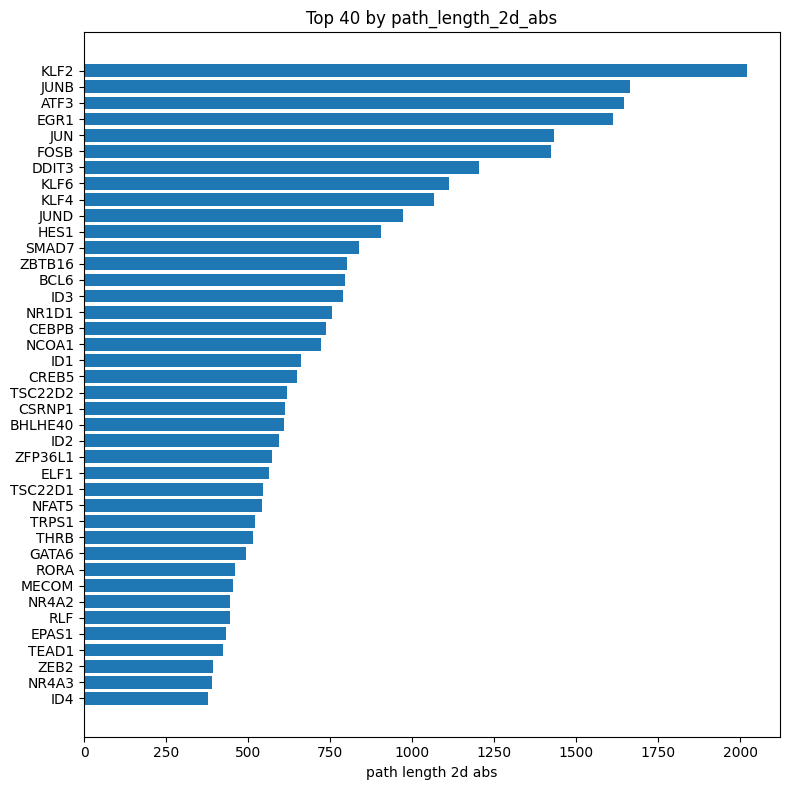

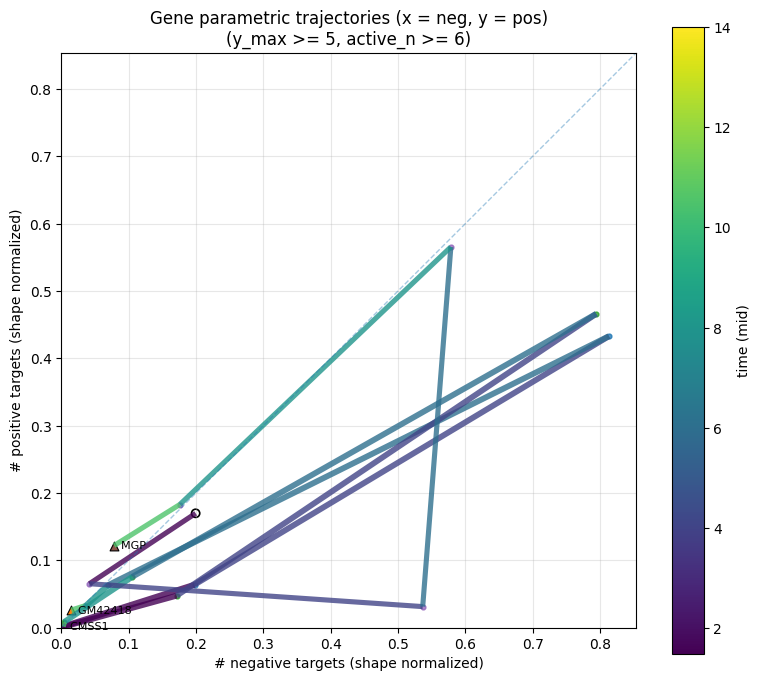

In [139]:
plot_top_changers(metrics, value_col="path_length_2d_abs", top_n=40, only_tf=True, min_y_max=10, min_active_n=6)
plot_parametric_curves(gene_counts, metrics, top_by="path_length_2d_abs", top_n=3, only_tf=False, min_y_max=5, min_active_n=6)

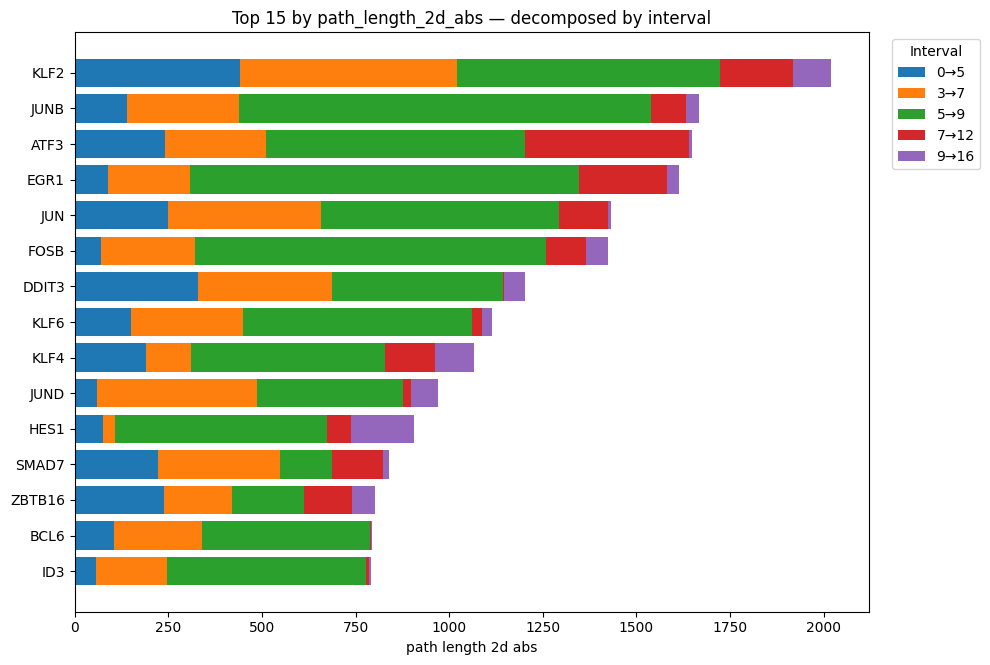

interval,0→5,3→7,5→9,7→12,9→16
gene,,,,,
KLF2,441.946829,578.249946,704.006392,192.761511,103.730420
JUNB,138.621788,300.820545,1098.116569,94.260278,34.014703
ATF3,240.070823,269.675731,693.541635,436.702416,7.615773
EGR1,90.138782,217.892175,1039.001444,234.931905,31.256999
JUN,248.131014,408.533964,636.777041,131.521861,7.211103
FOSB,69.778220,252.009920,935.558122,108.074049,57.271284
DDIT3,329.984848,356.585193,457.664724,2.000000,56.568542
KLF6,150.442680,298.529731,612.513673,27.294688,25.000000
KLF4,190.307646,119.774789,518.808250,132.879645,105.603030


In [142]:
plot_top_changers_stacked(
    gene_counts,
    metrics,
    value_col="path_length_2d_abs",
    top_n=15,
    only_tf=True,
    min_y_max=5,
    min_active_n=6,
)

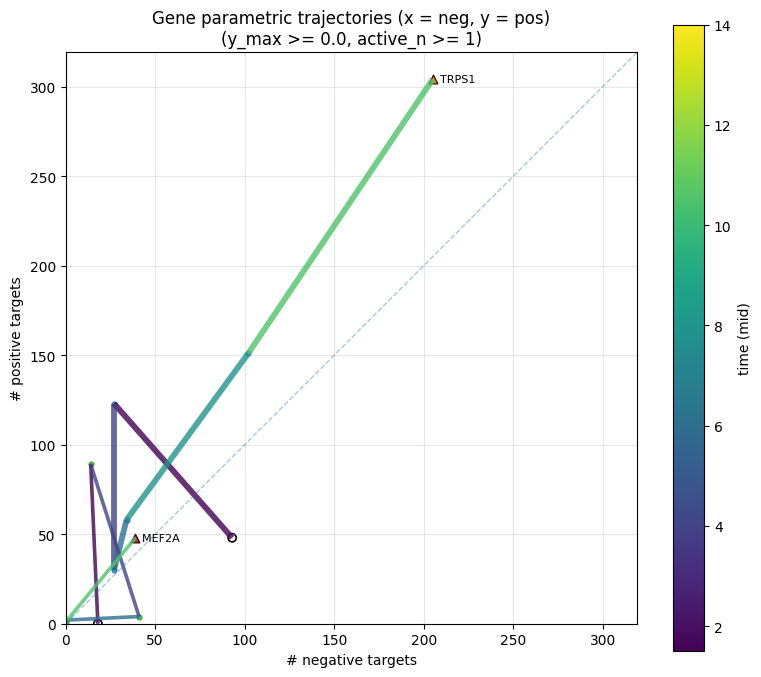

In [42]:
#VCAM1, KLF2, KLF4, EGR1, NR4A1, FOXO1, RBPJ, HIF1A, ID3, MALAT1, MGP, ANK
# ACTA2, TAGLN, PRDM6?
# CXCL12, FN1, TMSB4X, DCN, GATA6, EPAS1, ZEB2, NR1D1, BCL6, NFAT5, KLF6
# MYH11, CNN1, TPM2, LUM, ACTA2, TAGLN, CALD1 # = markers
plot_parametric_curves(
    gene_counts,
    genes=["TRPS1","MEF2A"],
    normalize_shape=False,
    metrics=metrics,
)

In [43]:
# Inspect the most variable TFs numerically:
metrics[(metrics["active_n"] >= 6) & (metrics["y_max"] > 5)].sort_values(by=["total_variation_shape"], ascending=False).head(5)

,gene,is_tf,active_n,y_max,total_variation_abs,total_variation_shape,path_length_2d_abs,path_length_2d_shape,balance_variation
5,RAB6B,False,6,105.0,416.0,4.160000,325.843897,3.258439,5.071148
9,ANK,False,6,163.0,632.0,4.057785,491.550692,3.156024,4.079333
26,PIEZO2,False,6,31.0,119.0,3.933884,95.925771,3.171100,3.175352
40,RANBP1,False,6,56.0,214.0,3.855856,174.359920,3.141620,5.047619
55,COBLL1,False,6,184.0,679.0,3.772222,529.148706,2.939715,1.290926


Clustering 1629 genes into 8 clusters...


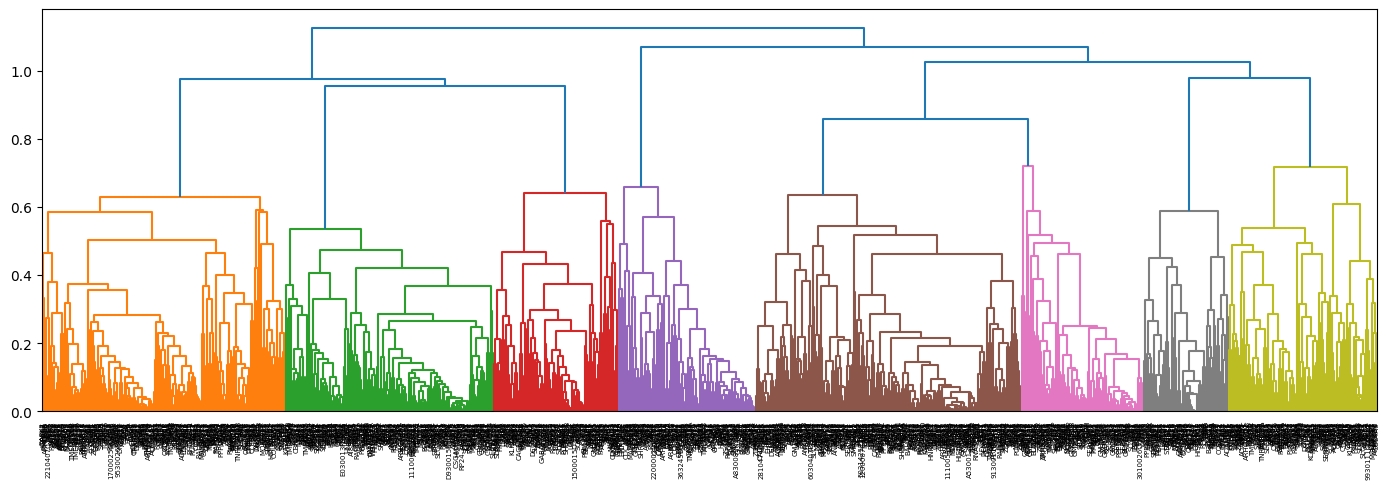

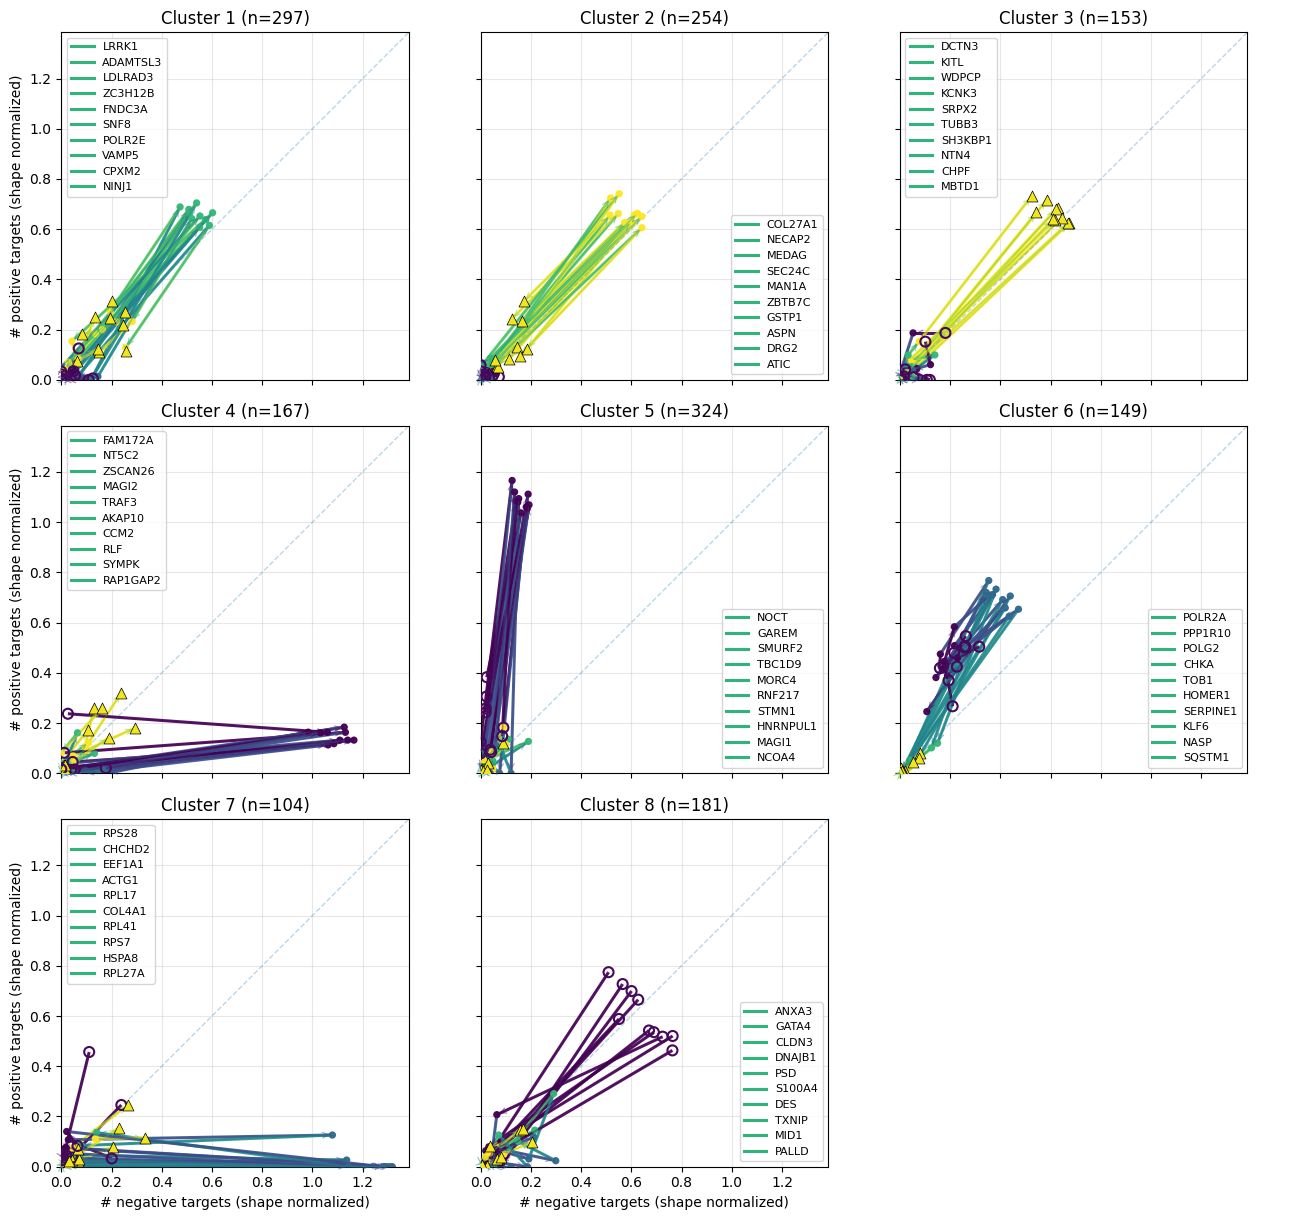

In [44]:
X_A, Z_A, clusters_A = cluster_A(gene_counts, n_clusters=8, only_tf=False, min_y_max=5, min_active_n=5)
plot_dendrogram_A(Z_A, X_A.index)
reps_A = plot_cluster_examples(gene_counts, X_A, clusters_A, n_per_cluster=10, normalize=True)

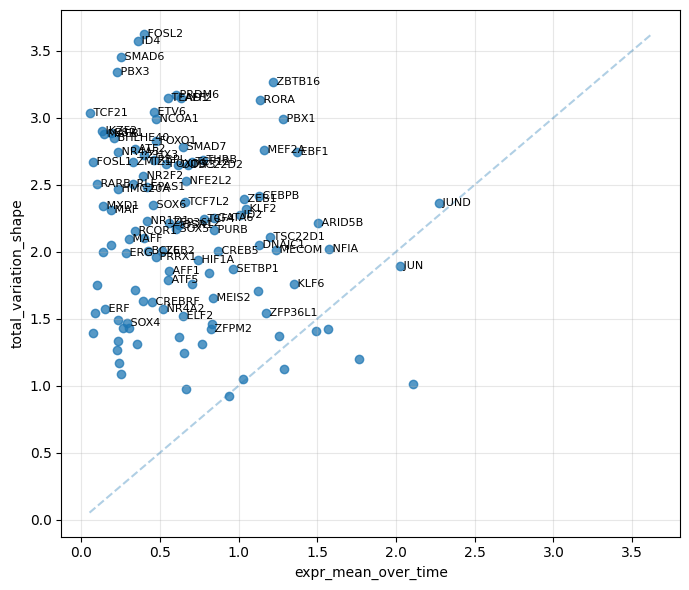

,gene,is_tf,active_n,y_max,total_variation_abs,total_variation_shape,path_length_2d_abs,path_length_2d_shape,balance_variation,expr_mean_over_time,expr_max,expr_active_n,expr_tv_shape,discordance,discordance_pred,discordance_resid
0,FOSL2,True,6,93.0,310.0,3.625731,244.380277,2.858249,6.034632,0.395261,0.462367,7,0.951819,2.673912,2.165433,1.460298
1,ID4,True,6,140.0,477.0,3.573034,379.199776,2.840448,4.281203,0.361756,0.541921,7,0.859175,2.713858,2.155621,1.417413
2,SMAD6,True,6,140.0,458.0,3.456604,374.060607,2.823099,1.870996,0.251809,0.333976,7,0.989479,2.467125,2.169422,1.287182
3,PBX3,True,6,42.0,132.0,3.341772,108.185245,2.738867,4.640476,0.228564,0.238359,7,0.327340,3.014433,2.099289,1.242483
4,ZBTB16,True,6,362.0,1120.0,3.270073,802.935949,2.344339,1.270622,1.214606,1.520848,7,0.795578,2.474495,2.148884,1.121189
5,TEAD1,True,6,187.0,566.0,3.144444,422.537550,2.347431,1.686909,0.550016,0.622317,7,0.400529,2.743915,2.107042,1.037403
6,RORA,True,6,178.0,522.0,3.135135,460.800190,2.767569,4.404762,1.134659,1.237025,7,0.336157,2.798978,2.100223,1.034912
7,PRDM6,True,6,97.0,281.0,3.166197,230.616514,2.598496,2.278032,0.600223,0.716692,7,0.832769,2.333428,2.152824,1.013374
8,AFF2,True,6,110.0,337.0,3.149533,332.087353,3.103620,4.596703,0.630570,0.758822,7,0.856833,2.292700,2.155372,0.994160
9,ETV6,True,6,143.0,418.0,3.040000,312.822249,2.275071,4.099174,0.458408,0.536711,7,0.820913,2.219087,2.151568,0.888432


In [45]:
path_adata = "/Users/cweinrei/Documents/temporalGRN/data/CAD/training_ready/test_case_CAD_04Mar.h5ad"
expr_table = build_expression_table(path_adata, time_col="time", scale_mode="q95")
expr_metrics = compute_expression_metrics(expr_table)
disc = discordance_table(metrics, expr_metrics, only_tf=True, min_y_max=5, min_active_n=6, reg_col="total_variation_shape")
plot_discordance_scatter(disc, x="expr_mean_over_time", y="total_variation_shape", score="discordance", top_n=80)
disc.head(30)
#most interesting plot to see HIGH variation of regulatory activity versus low expression mean over time
#TRPS1 put it?

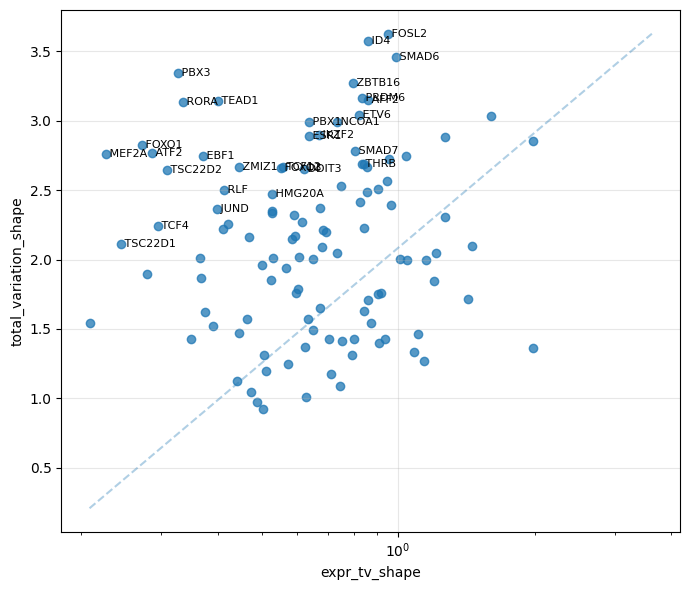

In [46]:
plot_discordance_scatter(disc, x="expr_tv_shape", y="total_variation_shape", score="discordance", top_n=30,log=True)
#most interesting plot to see HIGH variation of regulatory activity versus low expression mean over time
# here MEF2A is interesting, it has constant expression but high variation in regulation

In [47]:
disc.keys()

Index(['gene', 'is_tf', 'active_n', 'y_max', 'total_variation_abs',
       'total_variation_shape', 'path_length_2d_abs', 'path_length_2d_shape',
       'balance_variation', 'expr_mean_over_time', 'expr_max', 'expr_active_n',
       'expr_tv_shape', 'discordance', 'discordance_pred',
       'discordance_resid'],
      dtype='object')

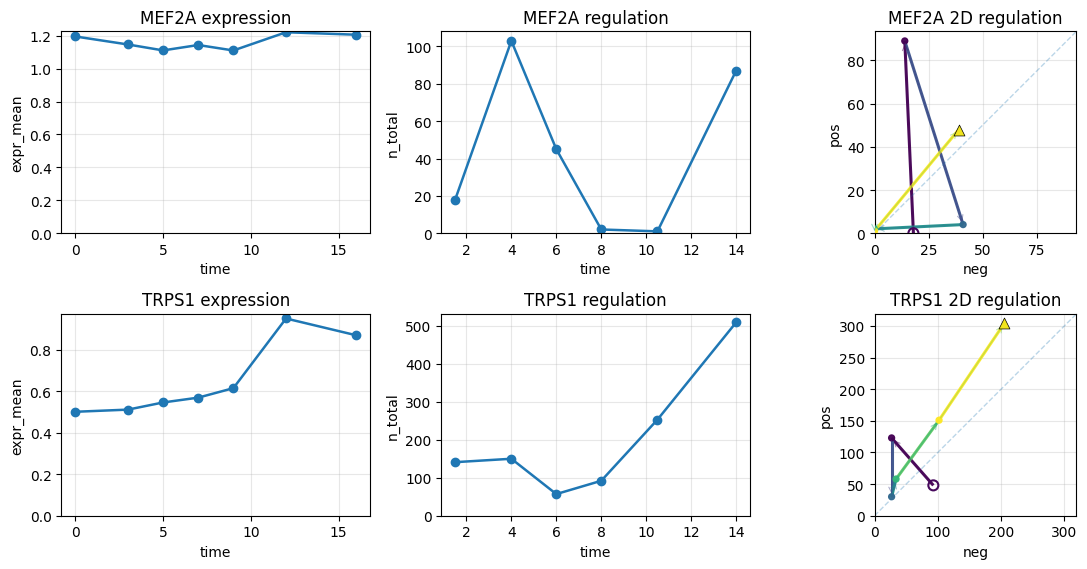

In [48]:
plot_top_discordant(gene_counts, expr_table, disc, score="discordance", normalize=False,genes=["MEF2A","TRPS1"])

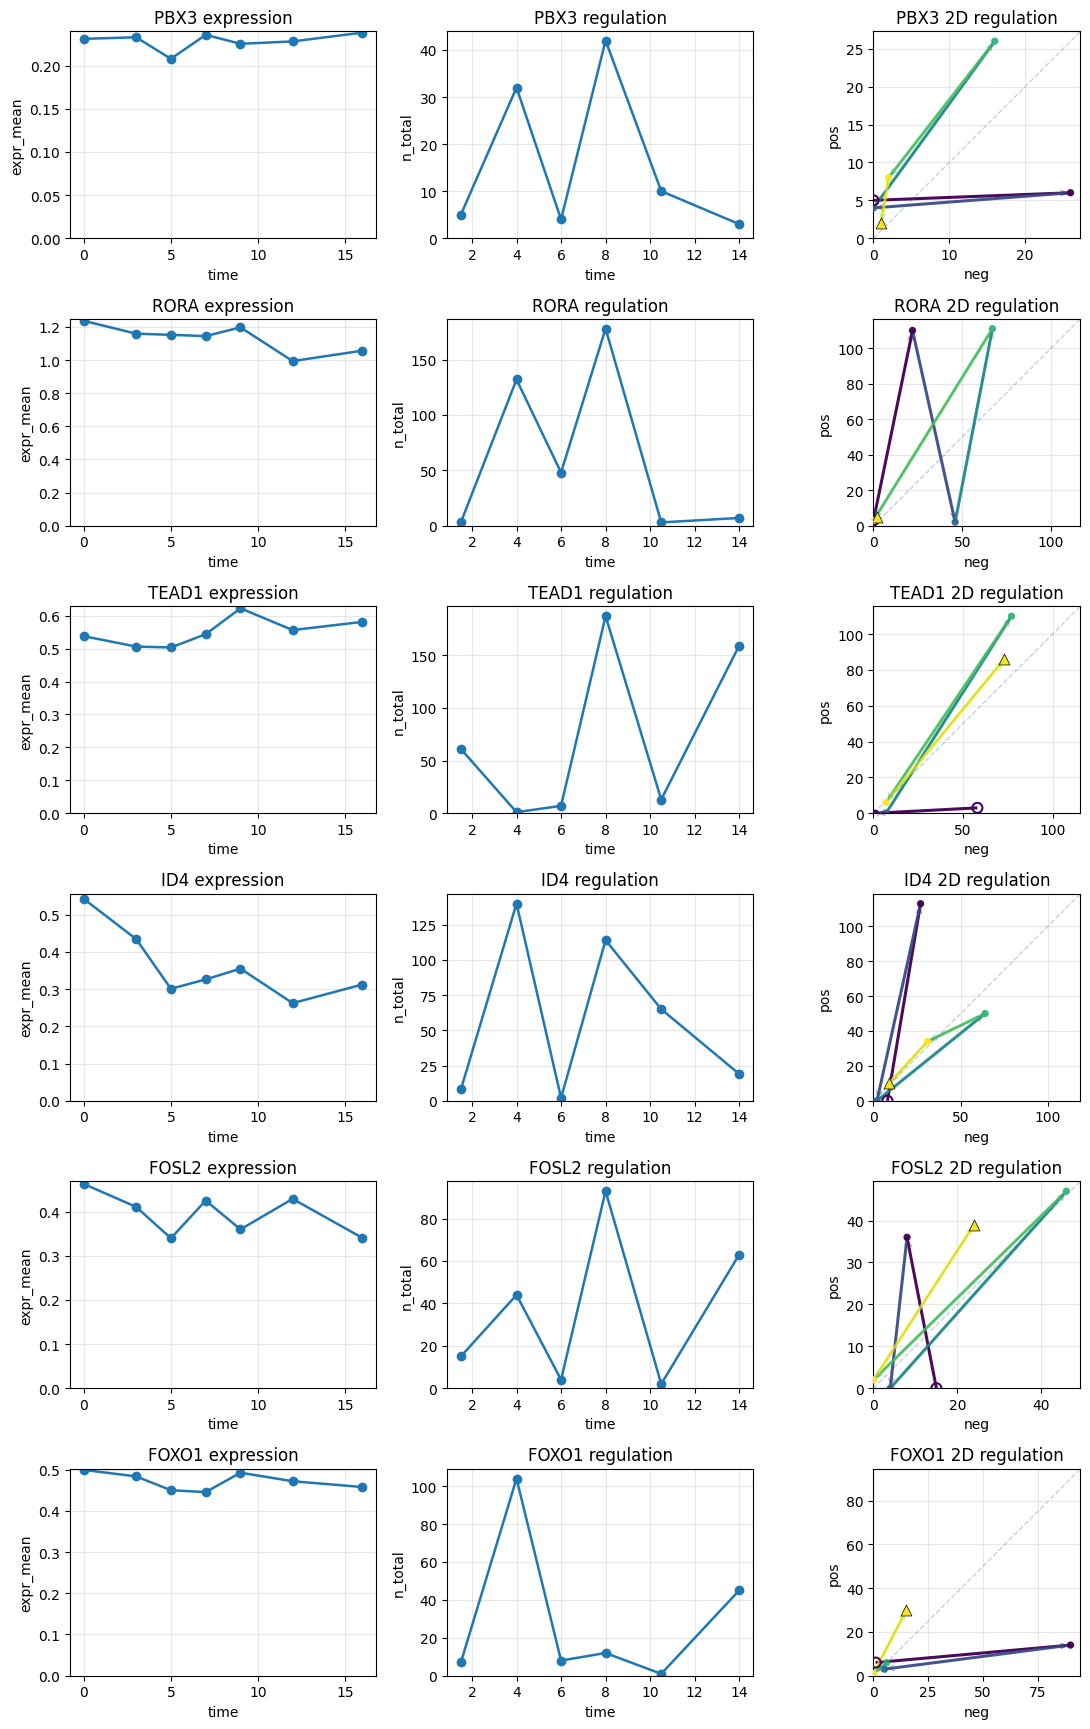

In [49]:
plot_top_discordant(gene_counts, expr_table, disc, top_n=6, score="discordance", normalize=False)
# int_df = interval_discordance(gene_counts, expr_table, disc)
# plot_interval_heatmap(int_df, disc, top_n=20)
# #lag_df = lag_table(gene_counts, expr_table, disc)
# #lag_df.head(20)

# correlation of nb targets with expression

In [50]:
from scipy.stats import pearsonr, spearmanr

def align_expression_to_windows(expr_table, gene_counts, align="source"):
    """Attach exact-time expression snapshots to regulation windows.
    By default, each window uses expression at its source timepoint."""
    if align not in {"source", "target"}:
        raise ValueError("align must be 'source' or 'target'")

    windows = (
        gene_counts[["time_label", "time_start", "time_end", "time_mid"]]
        .drop_duplicates()
        .sort_values(["time_start", "time_end"], kind="stable")
        .reset_index(drop=True)
    )

    windows = windows.copy()
    windows["time"] = windows["time_start"] if align == "source" else windows["time_end"]

    out = windows.merge(expr_table, on="time", how="left")
    return out.sort_values(["gene", "time_start", "time_end"], kind="stable").reset_index(drop=True)

def build_expr_target_table(
    gene_counts,
    expr_table,
    metrics=None,
    only_tf=True,
    min_y_max=5,
    min_active_n=6,
    align="source",
):
    """Merge regulation windows with aligned expression snapshots.
    Use align='source' or 'target' to choose which timepoint represents each window."""
    expr_win = align_expression_to_windows(expr_table, gene_counts, align=align)

    df = gene_counts.merge(
        expr_win[["gene", "time_label", "expr_mean", "expr_shape"]],
        on=["gene", "time_label"],
        how="inner",
    )

    if metrics is not None:
        keep = metrics.copy()
        if only_tf:
            keep = keep[keep["is_tf"]]
        keep = keep[(keep["y_max"] >= min_y_max) & (keep["active_n"] >= min_active_n)]
        df = df[df["gene"].isin(keep["gene"])].copy()
    elif only_tf:
        df = df[df["is_tf"]].copy()

    return df


def corr_expr_targets_per_time(df, x="expr_mean", y="n_total"):
    """Compute Pearson and Spearman correlations between expression and targets for each time window."""
    rows = []
    for tl, g in df.groupby("time_label", sort=False):
        xx = g[x].to_numpy(float)
        yy = g[y].to_numpy(float)
        if len(g) >= 3 and np.std(xx) > 0 and np.std(yy) > 0:
            rp, pp = pearsonr(xx, yy)
            rs, ps = spearmanr(xx, yy)
        else:
            rp = pp = rs = ps = np.nan
        rows.append({
            "time_label": tl,
            "n_genes": len(g),
            "pearson_r": rp,
            "pearson_p": pp,
            "spearman_r": rs,
            "spearman_p": ps,
        })
    return pd.DataFrame(rows)


def corr_expr_targets_averaged(df):
    """Average expression and targets over time for each gene, then compute global correlations."""
    avg = (
        df.groupby("gene", as_index=False)
        .agg(
            expr_mean_over_time=("expr_mean", "mean"),
            expr_shape_mean=("expr_shape", "mean"),
            targets_mean=("n_total", "mean"),
            targets_shape_mean=("n_total_shape", "mean"),
            targets_max=("n_total", "max"),
        )
    )

    def _corr(a, b):
        a = avg[a].to_numpy(float)
        b = avg[b].to_numpy(float)
        if len(avg) >= 3 and np.std(a) > 0 and np.std(b) > 0:
            rp, pp = pearsonr(a, b)
            rs, ps = spearmanr(a, b)
        else:
            rp = pp = rs = ps = np.nan
        return {"pearson_r": rp, "pearson_p": pp, "spearman_r": rs, "spearman_p": ps}

    summary = pd.DataFrame([
        {"x": "expr_mean_over_time", "y": "targets_mean", **_corr("expr_mean_over_time", "targets_mean")},
        {"x": "expr_mean_over_time", "y": "targets_max", **_corr("expr_mean_over_time", "targets_max")},
        {"x": "expr_shape_mean", "y": "targets_shape_mean", **_corr("expr_shape_mean", "targets_shape_mean")},
    ])
    return avg, summary


def plot_expr_targets_per_time(df, x="expr_mean", y="n_total", ncols=3, figsize_per_panel=(4.2, 4.0)):
    """Plot expression vs targets for each time window with Pearson/Spearman in the title."""
    corr = corr_expr_targets_per_time(df, x=x, y=y)

    time_order = (
        df[["time_label", "time_start", "time_end"]]
        .drop_duplicates()
        .sort_values(["time_start", "time_end"], kind="stable")["time_label"]
        .tolist()
    )

    n = len(time_order)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
        squeeze=False,
    )

    for ax, tl in zip(axes.flat, time_order):
        g = df[df["time_label"] == tl]
        ax.scatter(g[x], g[y], alpha=0.7, s=18)

        c = corr[corr["time_label"] == tl].iloc[0]
        ax.set_title(
            f"{tl}\nPearson={c['pearson_r']:.2f} | Spearman={c['spearman_r']:.2f}"
            if pd.notna(c["pearson_r"]) and pd.notna(c["spearman_r"])
            else f"{tl}\ninsufficient variation"
        )
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.grid(alpha=0.3)

    for ax in axes.flat[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()
    return corr


def plot_expr_targets_averaged(avg_df, x="expr_mean_over_time", y="targets_mean", label_top_n=12):
    """Plot averaged expression vs averaged targets and label the most target-rich genes."""
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.scatter(avg_df[x], avg_df[y], alpha=0.75)

    top = avg_df.nlargest(label_top_n, y)
    for _, row in top.iterrows():
        ax.text(row[x], row[y], f" {row['gene']}", fontsize=8, va="center")

    if len(avg_df) >= 3 and avg_df[x].std() > 0 and avg_df[y].std() > 0:
        rp, pp = pearsonr(avg_df[x], avg_df[y])
        rs, ps = spearmanr(avg_df[x], avg_df[y])
        ax.set_title(f"{y} vs {x}\nPearson={rp:.2f} (p={pp:.1e}) | Spearman={rs:.2f} (p={ps:.1e})")
    else:
        ax.set_title(f"{y} vs {x}")

    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

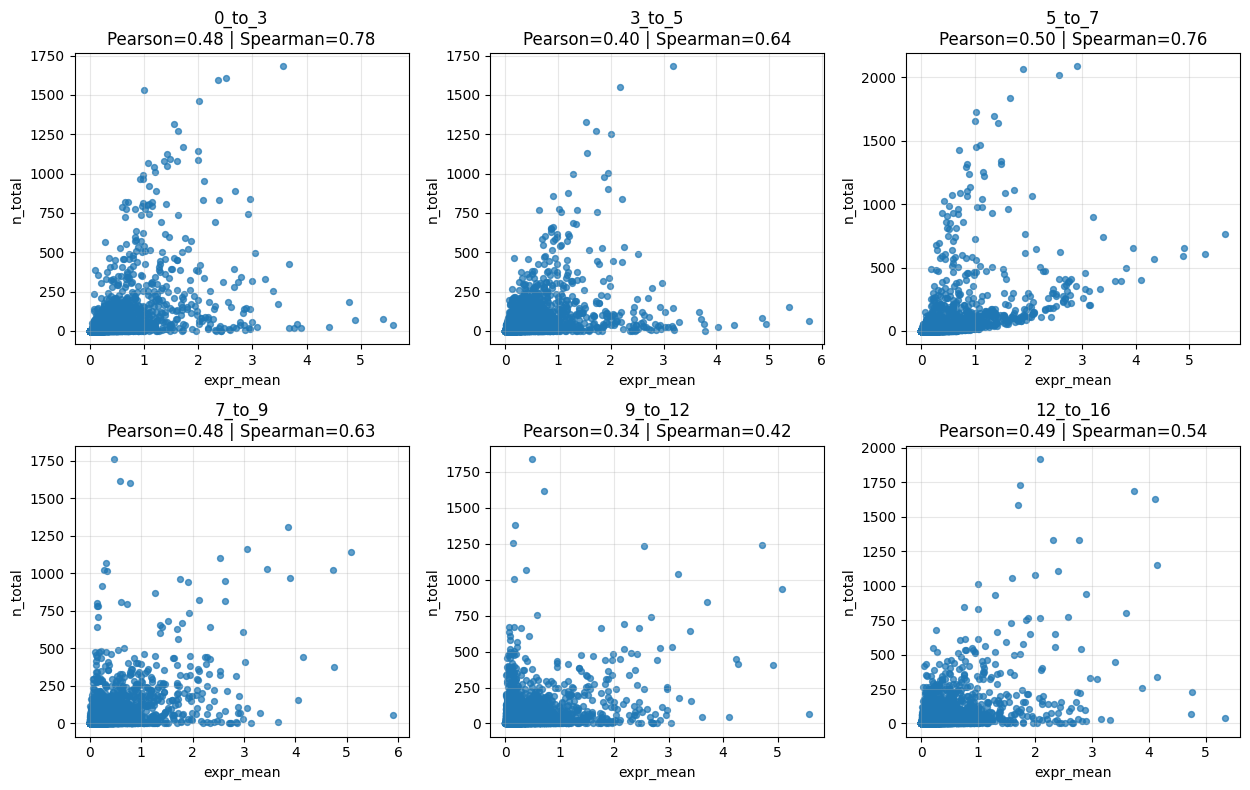

,time_label,n_genes,pearson_r,pearson_p,spearman_r,spearman_p
0,0_to_3,3273,0.483494,2.151596e-191,0.778107,0.000000e+00
1,3_to_5,3273,0.396550,1.057149e-123,0.642692,0.000000e+00
2,5_to_7,3273,0.498374,4.413449e-205,0.755977,0.000000e+00
3,7_to_9,3273,0.476143,7.056947e-185,0.627867,0.000000e+00
4,9_to_12,3273,0.344503,7.423273e-92,0.421403,4.513144e-141
5,12_to_16,3273,0.492781,7.401313e-200,0.543202,1.130807e-250


In [51]:
expr_target = build_expr_target_table(
    gene_counts,
    expr_table,
    metrics=metrics,
    only_tf=False,
    min_y_max=0,
    min_active_n=0,
)

corr_time = plot_expr_targets_per_time(
    expr_target,
    x="expr_mean",
    y="n_total",
    ncols=3,
)
corr_time

In [52]:
avg_tf, corr_avg = corr_expr_targets_averaged(expr_target)
corr_avg

,x,y,pearson_r,pearson_p,spearman_r,spearman_p
0,expr_mean_over_time,targets_mean,0.615022,0.000000e+00,0.786069,0.000000e+00
1,expr_mean_over_time,targets_max,0.574394,1.013338e-286,0.721426,0.000000e+00
2,expr_shape_mean,targets_shape_mean,0.372270,4.097830e-108,0.388543,2.048441e-118


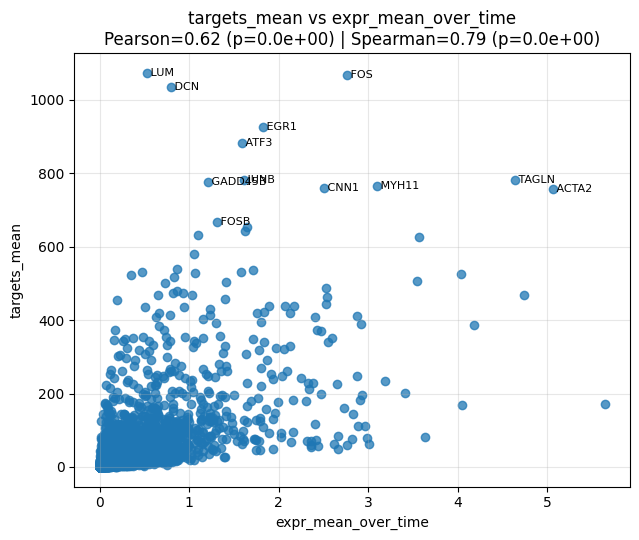

In [53]:
plot_expr_targets_averaged(
    avg_tf,
    x="expr_mean_over_time",
    y="targets_mean",
)


## TF cooperation over time

This section treats **TF cooperation as a time series for each TF pair**, not as a separate ranking at each window.

For each pair `(tf1, tf2)` and each time window it computes:

- `same` = shared targets with the **same sign**
- `opp` = shared targets with the **opposite sign**
- `j_same` = signed Jaccard based on same-sign overlap
- `j_unsigned` = unsigned Jaccard ignoring sign
- `opp_ratio` = fraction of shared targets that are opposite-sign
- `coop_balance` = `(same - opp) / (same + opp)`

Then it summarizes each pair across time with:

- `mean_j_same`, `max_j_same`
- `active_windows`, `longest_run`
- `mean_balance`, `switches`
- `persistent_score` for stable cooperation
- `antagonism_score` for persistent opposite-sign sharing

This can be run **independently** or annotated with the TF clusters from the previous section (`clusters_A`).


In [54]:

# TF cooperation over time

from collections import defaultdict
import itertools

def complete_pair_time_grid(pair_time: pd.DataFrame, gene_counts: pd.DataFrame) -> pd.DataFrame:
    """
    Complete the TF-pair x time grid so missing pair-time rows become zeros.
    Build a TF-pair by time table of shared targets.
    Stores same-sign overlap, opposite-sign overlap, and balance metrics.
    """
    if pair_time.empty:
        return pair_time.copy()

    # all time windows from the regulation table
    times = (
        gene_counts[["time_label", "time_start", "time_end", "time_mid"]]
        .drop_duplicates()
        .sort_values(["time_start", "time_end"], kind="stable")
        .reset_index(drop=True)
    )

    # pair metadata (one row per pair)
    pair_cols = ["tf1", "tf2"]
    extra_cols = [c for c in ["cluster1", "cluster2", "same_cluster"] if c in pair_time.columns]

    pairs = pair_time[pair_cols + extra_cols].drop_duplicates().reset_index(drop=True)

    # cross join pairs x times
    grid = pairs.merge(times, how="cross")

    # merge observed values
    out = grid.merge(
        pair_time,
        on=pair_cols + extra_cols + ["time_label", "time_start", "time_end", "time_mid"],
        how="left",
    )

    # fill missing metrics with zero
    fill_zero = [
        "same",
        "opp",
        "shared_unsigned",
        "j_same",
        "j_unsigned",
        "opp_ratio",
        "coop_balance",
    ]
    for c in fill_zero:
        if c in out.columns:
            out[c] = out[c].fillna(0.0)

    return out.sort_values(["tf1", "tf2", "time_start", "time_end"], kind="stable").reset_index(drop=True)

def build_pair_time_table(
    data_dir=DEFAULT_DATA_DIR,
    pattern=DEFAULT_PATTERN,
    top_n=DEFAULT_TOP_N,
    chunksize=DEFAULT_CHUNKSIZE,
    topn_per_tf=50,
    min_targets_per_tf=10,
    clusters=None,
    pair_scope="all",   # "all" | "within_cluster" | "between_cluster"
):
    """Summarize each TF pair across time.
    Returns persistence, balance, switching, and antagonism scores."""
    cluster_map = {} if clusters is None else clusters.drop_duplicates("gene").set_index("gene")["cluster"].to_dict()
    rows = []

    for rec in _file_index(data_dir, pattern).itertuples(index=False):
        dff = _load_top_edges(rec.file_path, top_n, chunksize)
        dff = dff[dff["gene1_is_TF"] == True].copy()
        if dff.empty:
            continue
        if topn_per_tf is not None:
            dff = (dff.sort_values(["gene1","strength"], ascending=[True, False])
                     .groupby("gene1", sort=False).head(topn_per_tf))
        dff = dff.sort_values("strength", ascending=False).drop_duplicates(["gene1","gene2","sign"], keep="first")

        pos = dff[dff["sign"] > 0].groupby("gene1")["gene2"].apply(set).to_dict()
        neg = dff[dff["sign"] < 0].groupby("gene1")["gene2"].apply(set).to_dict()

        kept = []
        for tf in sorted(set(pos) | set(neg)):
            u = len(pos.get(tf, set()) | neg.get(tf, set()))
            if u >= min_targets_per_tf:
                kept.append(tf)
        if len(kept) < 2:
            continue

        pos = {tf: pos.get(tf, set()) for tf in kept}
        neg = {tf: neg.get(tf, set()) for tf in kept}

        inv_pos, inv_neg = defaultdict(list), defaultdict(list)
        for tf, targets in pos.items():
            for g in targets: inv_pos[g].append(tf)
        for tf, targets in neg.items():
            for g in targets: inv_neg[g].append(tf)

        same, opp = defaultdict(int), defaultdict(int)
        for tfs in inv_pos.values():
            for a, b in itertools.combinations(sorted(tfs), 2): same[(a, b)] += 1
        for tfs in inv_neg.values():
            for a, b in itertools.combinations(sorted(tfs), 2): same[(a, b)] += 1
        for g in set(inv_pos) & set(inv_neg):
            for a in inv_pos[g]:
                for b in inv_neg[g]:
                    if a == b:
                        continue
                    x, y = (a, b) if a < b else (b, a)
                    opp[(x, y)] += 1

        for a, b in sorted(set(same) | set(opp)):
            c1, c2 = cluster_map.get(a), cluster_map.get(b)
            same_cluster = (c1 == c2) if (c1 is not None and c2 is not None) else np.nan
            if pair_scope == "within_cluster" and same_cluster != True:
                continue
            if pair_scope == "between_cluster" and same_cluster != False:
                continue

            same_n = same.get((a, b), 0)
            opp_n = opp.get((a, b), 0)

            sa = len(pos[a]) + len(neg[a])
            sb = len(pos[b]) + len(neg[b])
            ua = len(pos[a] | neg[a])
            ub = len(pos[b] | neg[b])

            signed_union = sa + sb - same_n
            unsigned_inter = same_n + opp_n
            unsigned_union = ua + ub - unsigned_inter

            j_same = same_n / signed_union if signed_union else 0.0
            j_unsigned = unsigned_inter / unsigned_union if unsigned_union else 0.0
            opp_ratio = opp_n / unsigned_inter if unsigned_inter else 0.0
            coop_balance = (same_n - opp_n) / unsigned_inter if unsigned_inter else 0.0

            rows.append({
                "time_label": rec.time_label,
                "time_start": rec.time_start,
                "time_end": rec.time_end,
                "time_mid": rec.time_mid,
                "tf1": a,
                "tf2": b,
                "cluster1": c1,
                "cluster2": c2,
                "same_cluster": same_cluster,
                "same": same_n,
                "opp": opp_n,
                "shared_unsigned": unsigned_inter,
                "j_same": j_same, # most important
                "j_unsigned": j_unsigned,
                "opp_ratio": opp_ratio, #among all shared targets, what fraction are opposite-sign rather than same-sign?
                "coop_balance": coop_balance, #are the two TFs mostly cooperating or mostly opposing each other? betwee -1 and 1
            })

    cols = ["time_label","time_start","time_end","time_mid","tf1","tf2","cluster1","cluster2","same_cluster",
            "same","opp","shared_unsigned","j_same","j_unsigned","opp_ratio","coop_balance"]

    pair_time = pd.DataFrame(rows,columns=cols)

    if pair_time.empty:
        return pair_time

    pair_time = pair_time.sort_values(
        ["tf1", "tf2", "time_start", "time_end"],
        kind="stable"
    ).reset_index(drop=True)

    pair_time = complete_pair_time_grid(pair_time, gene_counts)

    return pair_time


def summarize_pair_dynamics(
    pair_time: pd.DataFrame,
    j_thresh: float = 0.05, # activ thresohld
) -> pd.DataFrame:
    """
    Summarize TF-pair cooperation dynamics across the completed pair x time grid.
    """
    rows = []

    for (tf1, tf2), g in pair_time.groupby(["tf1", "tf2"], sort=False):
        g = g.sort_values(["time_start", "time_end"], kind="stable")

        j = g["j_same"].to_numpy(dtype=float)
        b = g["coop_balance"].to_numpy(dtype=float)

        active = j > j_thresh

        # longest consecutive run of active windows
        longest_run = 0
        run = 0
        for x in active:
            if x:
                run += 1
                longest_run = max(longest_run, run)
            else:
                run = 0

        # number of sign switches in coop_balance
        # only count switches between nonzero signs
        sign = np.sign(b)
        nz = sign != 0
        sign_nz = sign[nz]
        switches = int(np.sum(sign_nz[1:] != sign_nz[:-1])) if len(sign_nz) > 1 else 0

        row = {
            "tf1": tf1,
            "tf2": tf2,
            "mean_j_same": float(np.mean(j)), # on average, how strongly do these TFs cooperate over time?
            "max_j_same": float(np.max(j)),
            "active_windows": int(active.sum()), # in how many windows is the pair meaningfully cooperative? up to threshold
            "longest_run": int(longest_run), # how persistent is their cooperation through time?
            "mean_balance": float(np.mean(b)), #
            "balance_switches": int(switches), # does the pair switch from cooperating to antagonistic behavior?
            "tv_j_same": float(np.abs(np.diff(j)).sum()) if len(j) > 1 else 0.0,
            "tv_balance": float(np.abs(np.diff(b)).sum()) if len(b) > 1 else 0.0,
        }

        if "cluster1" in g.columns:
            row["cluster1"] = g["cluster1"].iloc[0]
        if "cluster2" in g.columns:
            row["cluster2"] = g["cluster2"].iloc[0]
        if "same_cluster" in g.columns:
            row["same_cluster"] = g["same_cluster"].iloc[0]

        # simple summary scores
        row["persistent_score"] = row["mean_j_same"] * row["longest_run"] * max(row["mean_balance"], 0)
        row["antagonism_score"] = row["mean_j_same"] * max(-row["mean_balance"], 0)

        rows.append(row)

    out = pd.DataFrame(rows)
    return out.sort_values(
        ["persistent_score", "mean_j_same", "longest_run"],
        ascending=[False, False, False],
        kind="stable",
    ).reset_index(drop=True)

def plot_top_pairs(summary, score="persistent_score", top_n=20):
    s = summary.sort_values(score, ascending=False).head(top_n).iloc[::-1].copy()
    labels = s["tf1"] + " :: " + s["tf2"]
    fig, ax = plt.subplots(figsize=(9, max(4, 0.35 * len(s))))
    ax.barh(labels, s[score])
    ax.set_xlabel(score)
    ax.set_title(f"Top {top_n} TF pairs by {score}")
    plt.tight_layout(); plt.show()


def plot_pair_summary_scatter(summary, x="mean_j_same", y="longest_run", color="mean_balance", top_n_labels=15):
    """Scatter two pair-summary metrics against each other.
    Useful to compare persistence, antagonism, and overlap strength."""
    fig, ax = plt.subplots(figsize=(7, 6))
    sc = ax.scatter(summary[x], summary[y], c=summary[color], s=40, alpha=.8)
    for _, r in summary.nlargest(top_n_labels, "persistent_score").iterrows():
        ax.text(r[x], r[y], f" {r['tf1']}::{r['tf2']}", fontsize=8, va="center")
    ax.set_xlabel(x); ax.set_ylabel(y); ax.set_title("TF-pair cooperation summary")
    ax.grid(alpha=.3)
    plt.colorbar(sc, ax=ax, shrink=.8, label=color)
    plt.tight_layout(); plt.show()


def plot_pair_heatmap(pair_time, summary, value="j_same", score="persistent_score", top_n=25):
    """Heatmap one pair metric across time for the top TF pairs.
Useful for spotting persistent or switching cooperation."""
    top = summary.sort_values(score, ascending=False).head(top_n).copy()
    top["pair"] = top["tf1"] + " :: " + top["tf2"]
    df = pair_time.merge(top[["tf1","tf2","pair"]], on=["tf1","tf2"], how="inner")
    order_rows = top["pair"].tolist()
    order_cols = (df[["time_label","time_start","time_end"]]
                  .drop_duplicates().sort_values(["time_start","time_end"])["time_label"].tolist())
    mat = df.pivot(index="pair", columns="time_label", values=value).reindex(index=order_rows, columns=order_cols)
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(mat))))
    im = ax.imshow(mat.to_numpy(float), aspect="auto")
    ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(mat.index)
    ax.set_xticks(range(len(mat.columns))); ax.set_xticklabels(mat.columns, rotation=90)
    ax.set_title(f"Top TF pairs — {value} over time")
    plt.colorbar(im, ax=ax, shrink=.8, label=value)
    plt.tight_layout(); plt.show()


def plot_pair_dynamics(pair_time, summary, score="persistent_score", top_n=9, ncols=3):
    """Plot the temporal cooperation profile of one TF pair.
Shows overlap and cooperation balance across time."""
    top = summary.sort_values(score, ascending=False).head(top_n)
    nrows = math.ceil(len(top) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.2*nrows), squeeze=False, sharex=True)
    for ax, (_, r) in zip(axes.flat, top.iterrows()):
        g = pair_time[(pair_time["tf1"] == r["tf1"]) & (pair_time["tf2"] == r["tf2"])].sort_values(["time_start","time_end"])
        t = g["time_mid"].to_numpy(float)
        ax.plot(t, g["j_same"], marker="o", label="j_same")
        ax.plot(t, g["opp_ratio"], marker="o", label="opp_ratio")
        ax.plot(t, g["coop_balance"], marker="o", label="balance")
        ax.set_title(f"{r['tf1']} :: {r['tf2']}")
        ax.grid(alpha=.3); ax.legend(fontsize=7)
    for ax in axes.flat[len(top):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()


def plot_cluster_pair_matrix(summary, score="persistent_score"):
    """Summarize cooperation scores between TF clusters.
Can reveal within-cluster and between-cluster cooperation patterns."""
    if "cluster1" not in summary.columns or summary["cluster1"].isna().all():
        raise ValueError("No cluster annotation found; pass clusters=clusters_A to build_pair_time_table.")
    s = summary.dropna(subset=["cluster1","cluster2"]).copy()
    s["cluster1"] = s["cluster1"].astype(int)
    s["cluster2"] = s["cluster2"].astype(int)
    s["cmin"] = s[["cluster1","cluster2"]].min(axis=1)
    s["cmax"] = s[["cluster1","cluster2"]].max(axis=1)
    mat = (s.groupby(["cmin","cmax"])[score].mean().unstack(fill_value=0).sort_index().sort_index(axis=1))
    # symmetrize for display
    full = mat.copy()
    for i in full.index:
        for j in full.columns:
            if j in full.index and i in full.columns:
                full.loc[j, i] = full.loc[i, j]
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(full.to_numpy(float), aspect="auto")
    ax.set_xticks(range(len(full.columns))); ax.set_xticklabels(full.columns)
    ax.set_yticks(range(len(full.index))); ax.set_yticklabels(full.index)
    ax.set_xlabel("cluster"); ax.set_ylabel("cluster")
    ax.set_title(f"Mean {score} by TF clusters")
    plt.colorbar(im, ax=ax, shrink=.8, label=score)
    plt.tight_layout(); plt.show()


In [55]:

# TF cooperation

pair_time = build_pair_time_table(
    data_dir=DEFAULT_DATA_DIR,
    pattern=DEFAULT_PATTERN,
    top_n=DEFAULT_TOP_N,
    topn_per_tf=50,
    min_targets_per_tf=10,
    clusters=clusters_A,      # optional; omit for independent analysis
    pair_scope="all",         # or "within_cluster" / "between_cluster"
)

pair_summary = summarize_pair_dynamics(pair_time, j_thresh=0.05)


Found 6 files matching pattern 'GeneGene_ranked_interactions_*.csv' in '/Users/cweinrei/Documents/results_benchmark_sync/maestro/2026-03-05_14-07-07testcase/0'


In [56]:
pair_summary.head(3)

,tf1,tf2,mean_j_same,max_j_same,active_windows,longest_run,mean_balance,balance_switches,tv_j_same,tv_balance,cluster1,cluster2,same_cluster,persistent_score,antagonism_score
0,NFAT5,NR4A2,0.562816,0.923077,6,6,1.000000,0,1.646422,0.000000,6.0,6.0,True,3.376898,0.0
1,EGR1,NR4A2,0.573852,0.923077,6,6,0.925926,0,1.046045,0.444444,6.0,6.0,True,3.188068,0.0
2,EGR1,JUNB,0.556424,0.923077,6,6,0.944444,0,1.226264,0.666667,6.0,6.0,True,3.153070,0.0


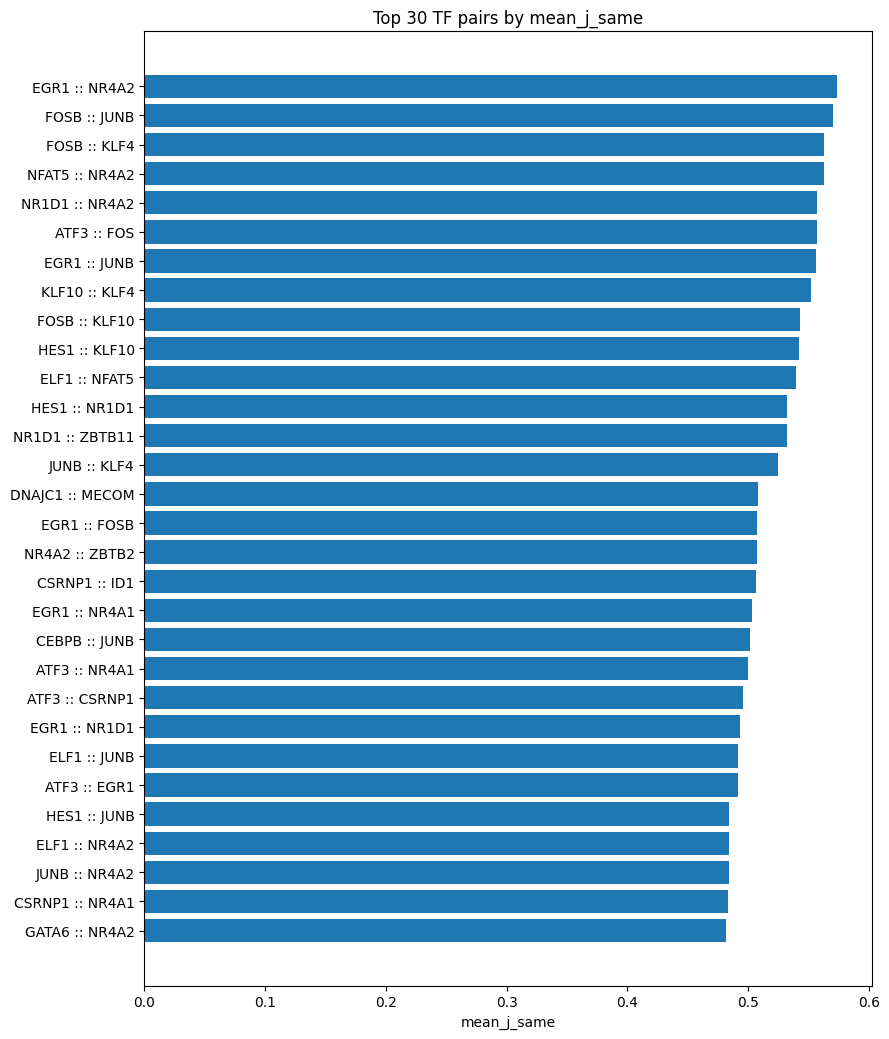

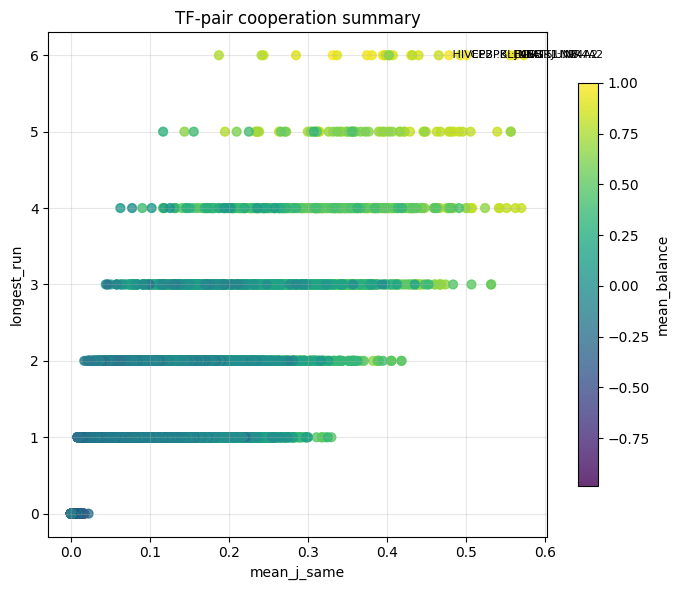

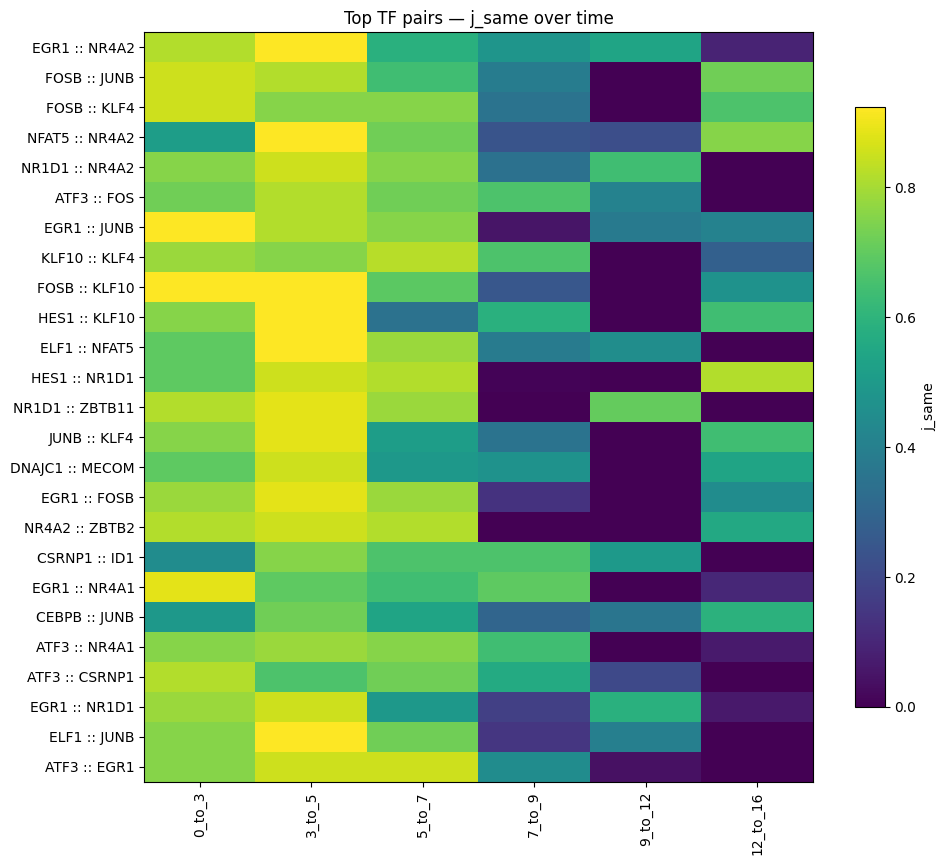

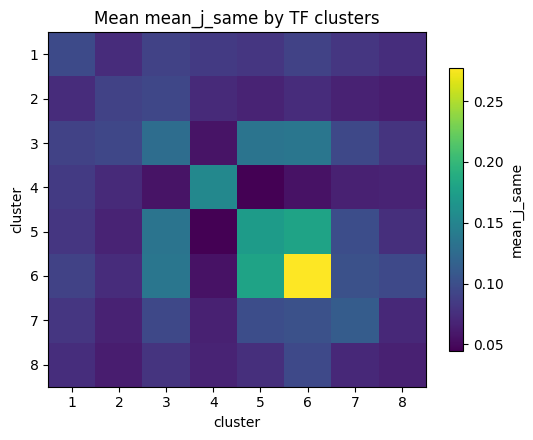

,tf1,tf2,mean_j_same,max_j_same,active_windows,longest_run,mean_balance,balance_switches,tv_j_same,tv_balance,cluster1,cluster2,same_cluster,persistent_score,antagonism_score
0,NFAT5,NR4A2,0.562816,0.923077,6,6,1.000000,0,1.646422,0.000000,6.0,6.0,True,3.376898,0.0
1,EGR1,NR4A2,0.573852,0.923077,6,6,0.925926,0,1.046045,0.444444,6.0,6.0,True,3.188068,0.0
2,EGR1,JUNB,0.556424,0.923077,6,6,0.944444,0,1.226264,0.666667,6.0,6.0,True,3.153070,0.0
3,CEBPB,JUNB,0.501145,0.724138,6,6,1.000000,0,0.946219,0.000000,6.0,6.0,True,3.006870,0.0
4,HIVEP2,KLF4,0.478838,0.818182,6,6,0.977778,0,1.361198,0.133333,6.0,6.0,True,2.809184,0.0
5,EGR1,NR1D1,0.492951,0.851852,6,6,0.916667,0,1.675822,0.500000,6.0,6.0,True,2.711230,0.0
6,ID2,NR4A2,0.430857,0.724138,6,6,0.962963,0,1.050013,0.444444,1.0,6.0,False,2.489398,0.0
7,KLF4,SOX4,0.397012,0.639344,6,6,1.000000,0,0.571048,0.000000,6.0,6.0,True,2.382072,0.0
8,JUND,NR1D1,0.465859,0.785714,6,6,0.833333,0,1.817470,2.000000,7.0,6.0,False,2.329297,0.0
9,EGR1,NFAT5,0.440392,0.886792,6,6,0.879085,0,1.139656,0.784314,6.0,6.0,True,2.322850,0.0


In [57]:
plot_top_pairs(pair_summary, score="mean_j_same", top_n=30)
plot_pair_summary_scatter(pair_summary, x="mean_j_same", y="longest_run", color="mean_balance", top_n_labels=5)
plot_pair_heatmap(pair_time, pair_summary, value="j_same", score="mean_j_same", top_n=25)
# plot_pair_heatmap(pair_time, pair_summary, value="coop_balance", score="mean_j_same", top_n=25)
# plot_pair_dynamics(pair_time, pair_summary, score="mean_j_same", top_n=9)

# optional, if clusters=clusters_A was passed above
plot_cluster_pair_matrix(pair_summary, score="mean_j_same")

pair_summary.head(20)

In [58]:
# find tcf21/tead1 pair
pair_summary[(pair_summary["tf1"] == "TCF21") & (pair_summary["tf2"] == "CEBPB") | (pair_summary["tf1"] == "CEBPB") & (pair_summary["tf2"] == "TCF21")]

,tf1,tf2,mean_j_same,max_j_same,active_windows,longest_run,mean_balance,balance_switches,tv_j_same,tv_balance,cluster1,cluster2,same_cluster,persistent_score,antagonism_score
21816,CEBPB,TCF21,0.024119,0.134615,1,1,-0.147059,2,0.269231,5.764706,6.0,2.0,False,0.0,0.003547


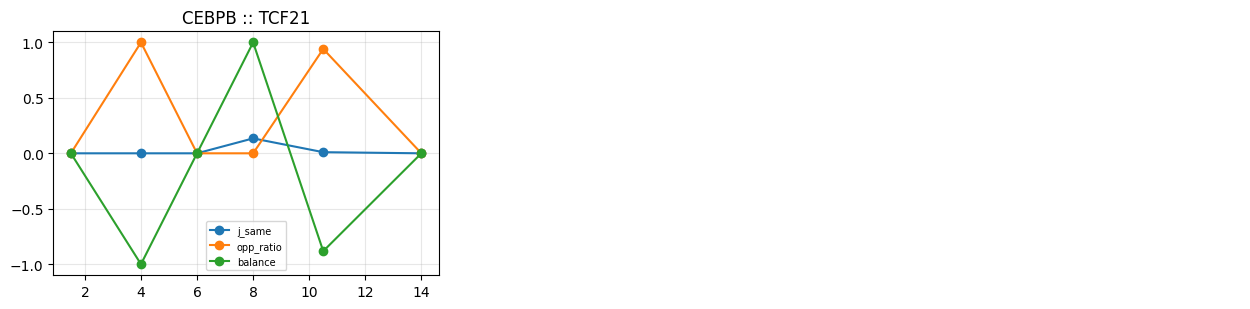

In [59]:
#plot TCF21/TEAD1 dynamics
plot_pair_dynamics(pair_time, pair_summary[(pair_summary["tf1"] == "TCF21") & (pair_summary["tf2"] == "TEAD1") | (pair_summary["tf1"] == "CEBPB") & (pair_summary["tf2"] == "TCF21")], score="mean_j_same", top_n=1)

In [60]:
import pickle

to_save = {
    # optional but useful if you want annotations later:
    "metrics": metrics if "metrics" in globals() else None,
    "disc": disc if "disc" in globals() else None,
    "clusters_A": clusters_A if "clusters_A" in globals() else None,
}

with open("network_outputs.pkl", "wb") as f:
    pickle.dump(to_save, f)

# new analysis

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def expression_logfc_from_expr_table(expr_table, t0, t1, pseudocount=1e-6):
    """Compute gene-wise log2 fold-change between two exact sampled timepoints from expr_table."""
    e0 = (
        expr_table[expr_table["time"] == float(t0)][["gene", "expr_mean"]]
        .rename(columns={"expr_mean": "expr_t0"})
    )
    e1 = (
        expr_table[expr_table["time"] == float(t1)][["gene", "expr_mean"]]
        .rename(columns={"expr_mean": "expr_t1"})
    )

    out = e0.merge(e1, on="gene", how="inner")
    out["expr_logFC"] = np.log2(out["expr_t1"] + pseudocount) - np.log2(out["expr_t0"] + pseudocount)
    return out[["gene", "expr_logFC"]]

def regulation_proxy_from_gene_counts(gene_counts, t0, t1, value_col="n_total_shape"):
    """Extract one TF/gene regulatory proxy from gene_counts for a single transition."""
    out = gene_counts[
        (gene_counts["time_start"] == float(t0)) &
        (gene_counts["time_end"] == float(t1))
    ][["gene", value_col,"is_tf"]].copy()

    out = out.rename(columns={value_col: "reg_value"})
    return out


def plot_expr_vs_reg(
    expr_df,
    reg_df,
    x_col="expr_logFC",
    y_col="reg_value",
    title="Expression vs regulation",
    label_genes=None,
    top_n_labels=12,
    figsize=(7, 7),
    only_tf=False,
    metrics=None,
):
    """Plot differential expression against a regulatory proxy or differential regulation.
    Set only_tf=True to restrict the plot to TFs using metrics['is_tf']."""
    df = expr_df.merge(reg_df, on="gene", how="inner").dropna()

    if only_tf:
        if metrics is None or "is_tf" not in metrics.columns:
            raise ValueError("metrics with an 'is_tf' column must be provided when only_tf=True")
        tf_genes = set(metrics.loc[metrics["is_tf"], "gene"].astype(str).str.upper())
        df = df[df["gene"].isin(tf_genes)].copy()

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(df[x_col], df[y_col], alpha=0.7, s=20)
    ax.axvline(0, color="black", lw=1)
    ax.axhline(0, color="black", lw=1)

    if label_genes is not None:
        label_set = set(pd.Index(label_genes).astype(str).str.upper())
        lab = df[df["gene"].isin(label_set)]
    else:
        score = np.abs(df[y_col]) + 1/(np.abs(df[x_col]) + 1) # simple scoring to label genes with high regulation and/or expression change
        lab = df.loc[score.nlargest(top_n_labels).index]
        print("genes labeled:", lab["gene"].tolist())

    for _, r in lab.iterrows():
        ax.text(r[x_col], r[y_col], f" {r['gene']}", fontsize=6, va="center")

    ax.set_xlabel("Differential expression log2(FC)")
    ax.set_ylabel("Regulatory activity")
    ax.set_title(title + (" — TFs only" if only_tf else ""))
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df

genes labeled: ['TRPS1', 'SOX9', 'TSC22D1', 'BHLHE40', 'RUNX1', 'SCX', 'HES1', 'ZEB2', 'TEAD1', 'MECOM', 'KLF4', 'KLF2', 'HIVEP3', 'ATF5', 'NR2F2', 'SOX6', 'ZBTB16', 'AFF2', 'SETBP1', 'TCF4']


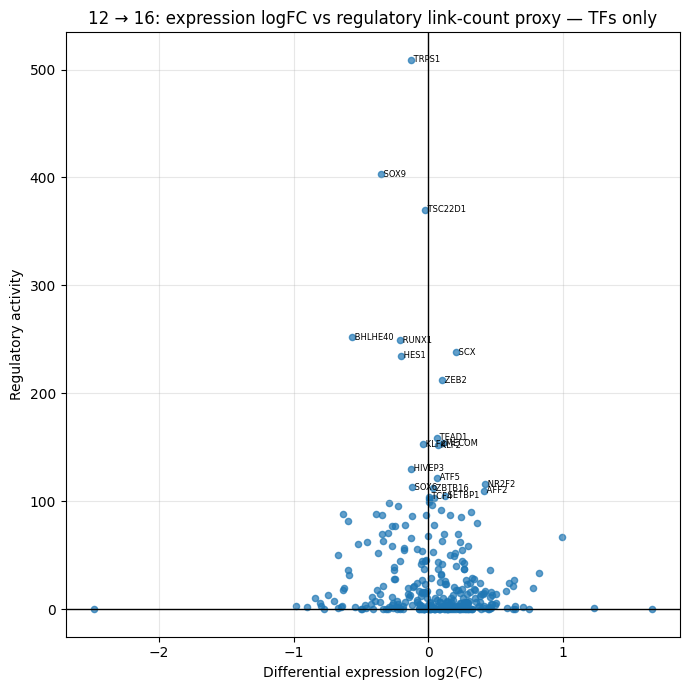

In [100]:
t0=12
t1=16

expr_12_16 = expression_logfc_from_expr_table(expr_table, t0, t1)


reg_12_16 = regulation_proxy_from_gene_counts(
    gene_counts,
    t0, t1,
    value_col="n_total",   # or "n_total_shape
)

df_12_16 = plot_expr_vs_reg(
    expr_12_16,
    reg_12_16,
    x_col="expr_logFC",
    y_col="reg_value",
    title=f"{t0} → {t1}: expression logFC vs regulatory link-count proxy",
    only_tf=True,
    metrics=metrics,
    top_n_labels=20,
)

# pair analysis

167
13861


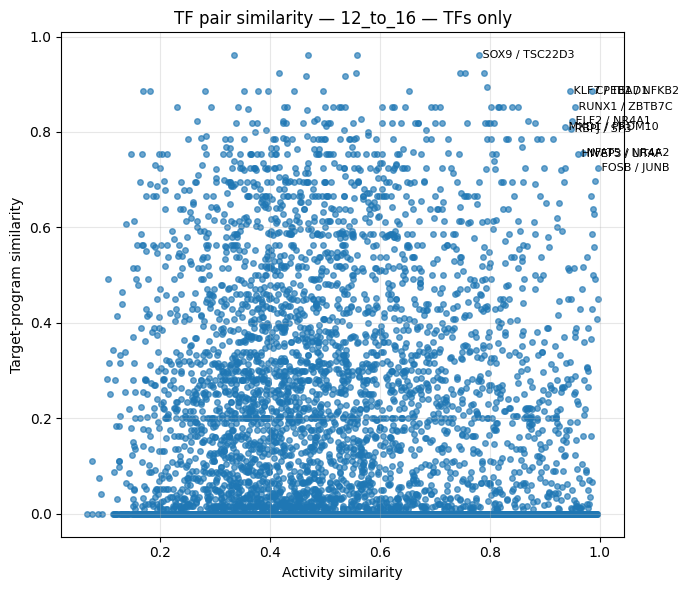

In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import MDS


def activity_similarity_from_XA(X_A):
    """TF-by-TF activity similarity from Option A features using correlation."""
    genes = X_A.index.tolist()
    D = squareform(pdist(X_A.to_numpy(dtype=float), metric="correlation"))
    S = 1.0 - D / 2.0   # convert correlation distance in [0,2] to similarity in [0,1]
    S = np.clip(S, 0, 1)
    return pd.DataFrame(S, index=genes, columns=genes)

def target_similarity_from_pair_time(pair_time, genes=None, mode="top3_mean", time_label=None):
    """TF-by-TF similarity from target overlap.
    mode='single_transition' uses j_same at one transition.
    mode='top3_mean' uses the mean of the 3 highest j_same values across time."""
    if mode == "single_transition":
        if time_label is None:
            raise ValueError("time_label must be provided when mode='single_transition'")
        pt = pair_time[pair_time["time_label"] == time_label].copy()
        pair_score = pt.groupby(["tf1", "tf2"], as_index=False)["j_same"].mean()
        pair_score = pair_score.rename(columns={"j_same": "score"})

    elif mode == "top3_mean":
        rows = []
        for (a, b), g in pair_time.groupby(["tf1", "tf2"], sort=False):
            vals = np.sort(g["j_same"].to_numpy(dtype=float))
            top = vals[-3:] if len(vals) >= 3 else vals
            rows.append({"tf1": a, "tf2": b, "score": float(np.mean(top)) if len(top) else 0.0})
        pair_score = pd.DataFrame(rows)

    else:
        raise ValueError("mode must be 'single_transition' or 'top3_mean'")

    if genes is None:
        genes = sorted(set(pair_score["tf1"]) | set(pair_score["tf2"]))

    S = pd.DataFrame(0.0, index=genes, columns=genes)
    np.fill_diagonal(S.values, 1.0)

    for _, r in pair_score.iterrows():
        a, b, s = r["tf1"], r["tf2"], float(r["score"])
        if a in S.index and b in S.columns:
            S.loc[a, b] = s
            S.loc[b, a] = s

    return S

def plot_tf_pair_scatter(
    X_A,
    pair_time,
    mode="top3_mean",
    time_label=None,
    label_top_n=20,
    only_tf=False,
    metrics=None,
):
    """Scatter of TF pairs: activity similarity vs target-program similarity.
    Set only_tf=True to restrict to TFs using metrics['is_tf']."""
    genes = X_A.index.tolist()

    if only_tf:
        if metrics is None or "is_tf" not in metrics.columns:
            raise ValueError("metrics with an 'is_tf' column must be provided when only_tf=True")
        tf_genes = set(metrics.loc[metrics["is_tf"], "gene"].astype(str).str.upper())
        genes = [g for g in genes if g in tf_genes]
        X_A = X_A.loc[genes]

    print(len(genes))
    S_act = activity_similarity_from_XA(X_A)
    S_tgt = target_similarity_from_pair_time(
        pair_time,
        genes=genes,
        mode=mode,
        time_label=time_label,
    )

    rows = []
    for i in range(len(genes)):
        for j in range(i + 1, len(genes)):
            a, b = genes[i], genes[j]
            rows.append(
                {
                    "tf1": a,
                    "tf2": b,
                    "activity_similarity": float(S_act.loc[a, b]),
                    "target_similarity": float(S_tgt.loc[a, b]),
                }
            )
    print(len(rows))
    df = pd.DataFrame(rows)
    df["pair"] = df["tf1"] + " / " + df["tf2"]

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(df["activity_similarity"], df["target_similarity"], alpha=0.65, s=16)
    ax.set_xlabel("Activity similarity")
    ax.set_ylabel("Target-program similarity")

    title = "TF pair similarity"
    if mode == "single_transition":
        title += f" — {time_label}"
    elif mode == "top3_mean":
        title += " — top-3 mean j_same"
    if only_tf:
        title += " — TFs only"
    ax.set_title(title)
    ax.grid(alpha=0.3)

    score = df["activity_similarity"] + df["target_similarity"]
    top = df.loc[score.nlargest(label_top_n).index]
    for _, r in top.iterrows():
        ax.text(r["activity_similarity"], r["target_similarity"], f" {r['pair']}", fontsize=8, va="center")

    plt.tight_layout()
    plt.show()

    return df


pair_scatter_12_16 = plot_tf_pair_scatter(
    X_A,
    pair_time,
    mode="single_transition",
    time_label="12_to_16",   # or "12-16" depending on your labels
    label_top_n=10,
    only_tf=True,
    metrics=metrics,
)

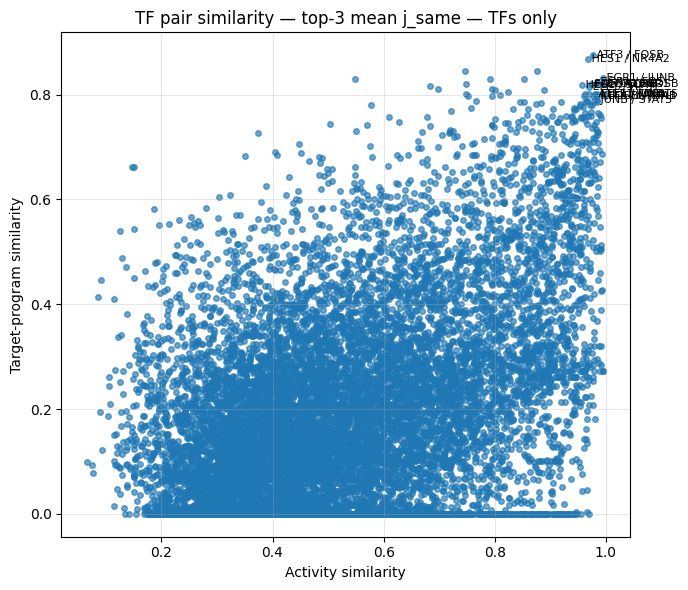

In [116]:
pair_scatter_top3 = plot_tf_pair_scatter(
    X_A,
    pair_time,
    mode="top3_mean",
    label_top_n=15,
    only_tf=True,
    metrics=metrics,
)

167


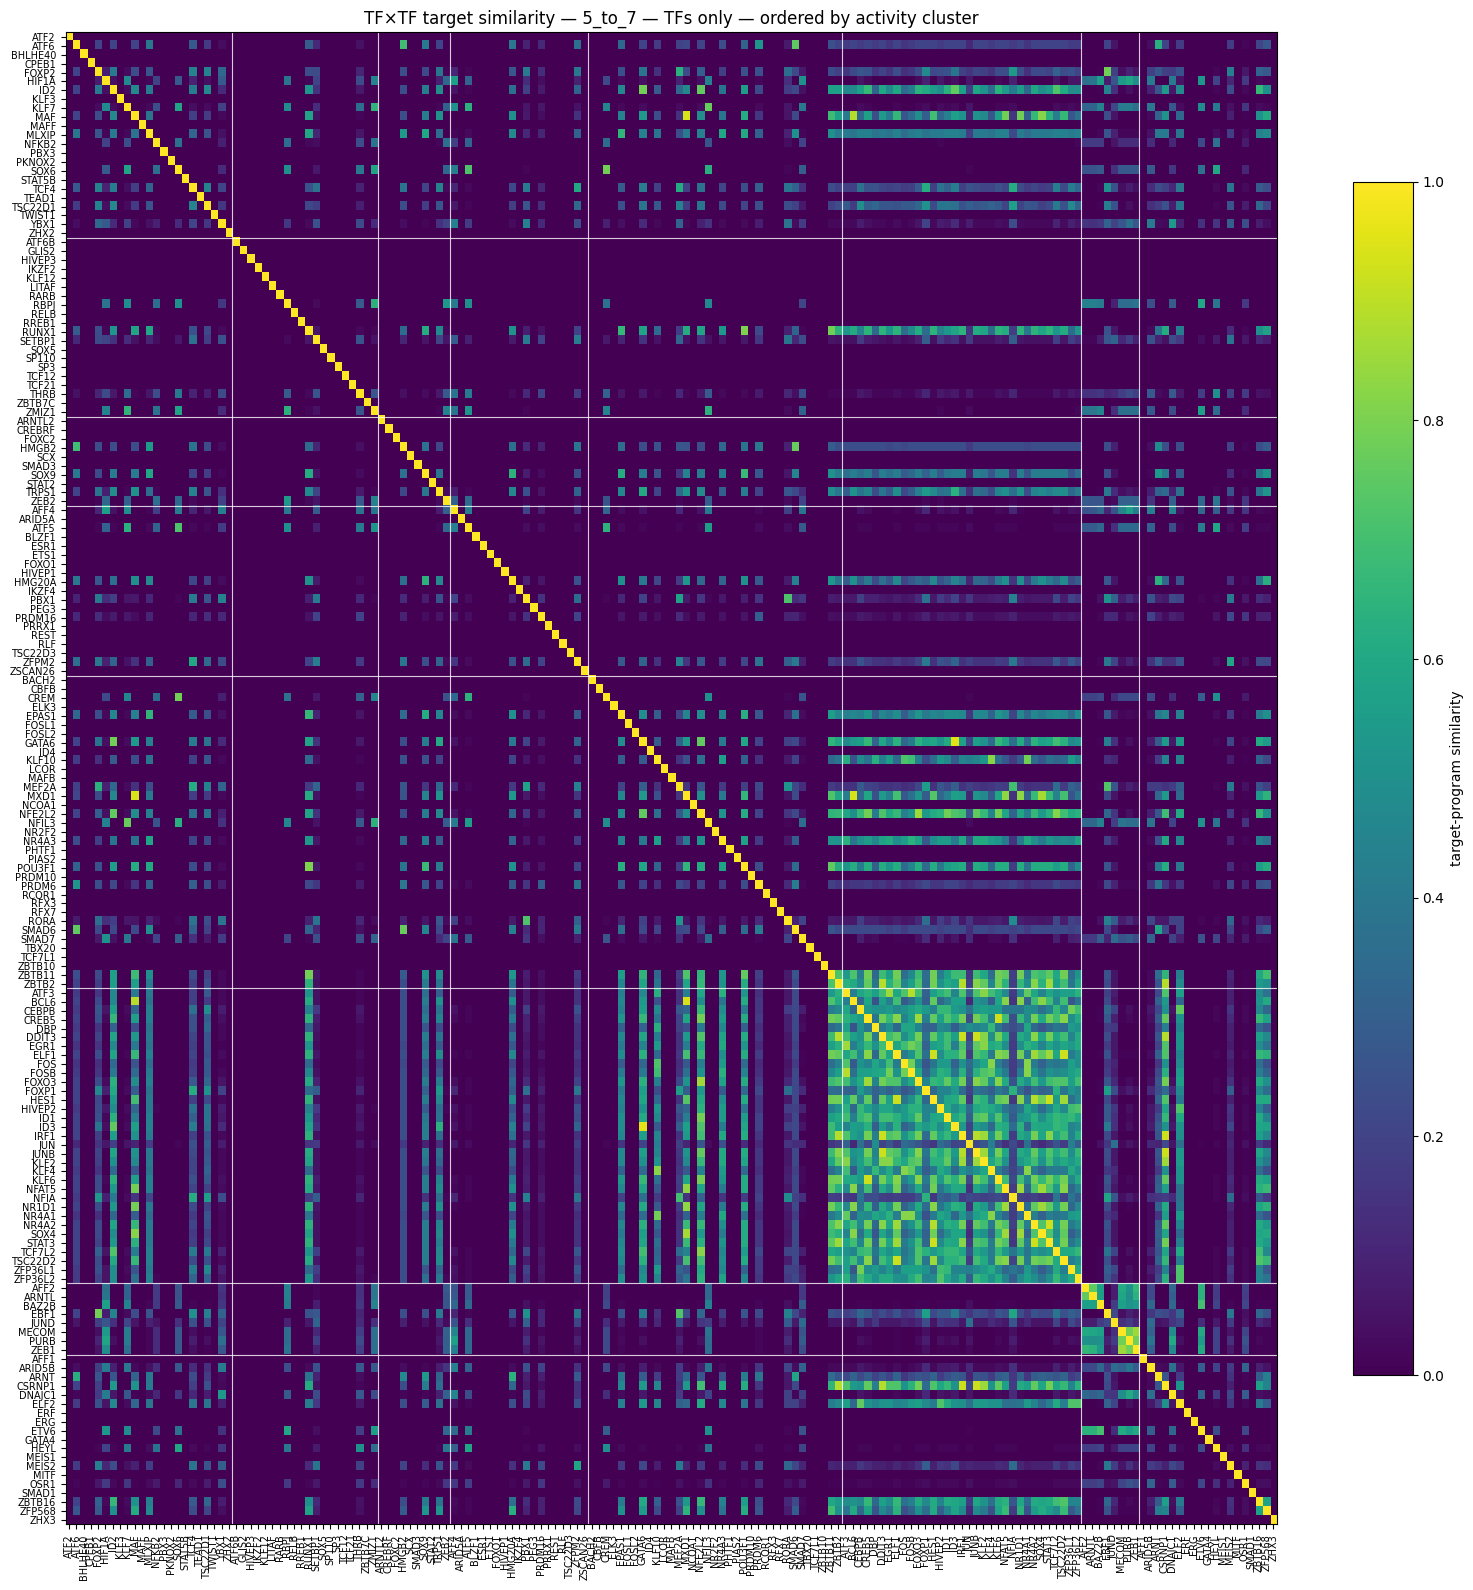

In [130]:
def plot_tf_target_similarity_heatmap(
    X_A,
    pair_time,
    mode="top3_mean",
    time_label=None,
    only_tf=False,
    metrics=None,
    clusters=None,
    cluster_col="cluster",
    figsize=(10, 9),
    cmap="viridis",
):
    """Heatmap of TF×TF target-program similarity, optionally ordered by activity clusters."""
    genes = X_A.index.tolist()

    if only_tf:
        if metrics is None or "is_tf" not in metrics.columns:
            raise ValueError("metrics with an 'is_tf' column must be provided when only_tf=True")
        tf_genes = set(metrics.loc[metrics["is_tf"], "gene"].astype(str).str.upper())
        genes = [g for g in genes if g in tf_genes]
    print(len(genes))

    S_tgt = target_similarity_from_pair_time(
        pair_time,
        genes=genes,
        mode=mode,
        time_label=time_label,
    )

    # ordering
    if clusters is not None:
        cl = clusters.copy()
        cl["gene"] = cl["gene"].astype(str).str.upper()
        cl = cl[cl["gene"].isin(genes)].copy()

        order_df = (
            cl[["gene", cluster_col]]
            .drop_duplicates()
            .sort_values([cluster_col, "gene"], kind="stable")
        )
        ordered_genes = order_df["gene"].tolist()

        # include any genes missing from cluster table at the end
        missing = [g for g in genes if g not in set(ordered_genes)]
        ordered_genes = ordered_genes + missing
    else:
        ordered_genes = sorted(genes)

    S_plot = S_tgt.loc[ordered_genes, ordered_genes]

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(S_plot.values, aspect="auto", cmap=cmap, vmin=0, vmax=max(1e-12, float(S_plot.values.max())))

    ax.set_xticks(range(len(ordered_genes)))
    ax.set_xticklabels(ordered_genes, rotation=90, fontsize=7)
    ax.set_yticks(range(len(ordered_genes)))
    ax.set_yticklabels(ordered_genes, fontsize=7)

    title = "TF×TF target similarity"
    if mode == "single_transition":
        title += f" — {time_label}"
    elif mode == "top3_mean":
        title += " — top-3 mean j_same"
    if only_tf:
        title += " — TFs only"
    if clusters is not None:
        title += " — ordered by activity cluster"
    ax.set_title(title)

    # draw cluster boundaries if clusters are provided
    if clusters is not None:
        prev = None
        boundaries = []
        for i, g in enumerate(ordered_genes):
            row = cl[cl["gene"] == g]
            c = row[cluster_col].iloc[0] if len(row) else None
            if prev is None:
                prev = c
            elif c != prev:
                boundaries.append(i - 0.5)
                prev = c

        for b in boundaries:
            ax.axhline(b, color="white", lw=0.8, alpha=0.8)
            ax.axvline(b, color="white", lw=0.8, alpha=0.8)

    plt.colorbar(im, ax=ax, shrink=0.8, label="target-program similarity")
    plt.tight_layout()
    plt.show()

    return S_plot


S_heat_12_16 = plot_tf_target_similarity_heatmap(
    X_A,
    pair_time,
    mode= "single_transition",#"top3_mean",#"single_transition",
    time_label="5_to_7",   # adapt to your exact label format
    only_tf=True,
    metrics=metrics,
    clusters=clusters_A,
    figsize=(16,16)
)